# `econ_anlys_fll_pct_dth_exr.ipynb` — COVID-19 Daily Death Rate Impact on Exchange Rate Returns: Full Period

> **File:** `econ_anlys_fll_pct_dth_exr.ipynb`
> **Purpose:** Analyze the causal and predictive relationship between the daily percentage change in COVID-19 deaths (`covid_deaths` %) and the percentage change in five exchange rates (`exchg_rts` %) across the full pandemic dataset (01/22/2020 – 09/14/2022).
> **Programmer:** Nicholas J. George  |  **Initial Development:** 04/10/2026

---

## Overview

This notebook examines whether daily COVID-19 death percentage changes Granger-caused movements in exchange rate returns across the entire 966-day pandemic dataset. It is the only full-period analysis in the project and the only notebook to use the raw, unsmoothed, non-cumulative death series — `xcml = False`, `x_roll = False` — making it analytically distinct from every other notebook in this sequence in a structurally important way. Where prior analyses applied a 7-day rolling average and cumulative accumulation to dampen noise, here the X series is the raw daily percentage change in COVID deaths: a high-variance, zero-mean series that spikes at weekly reporting cycles and around major pandemic wave events.

The Full Period composite score of 51.81 is the lowest of the four optimal candidates identified in the project, reflecting the expected averaging effect of pooling three structurally different pandemic phases — each with its own causal regime — into a single 966-day window. However, the identification of `covid_deaths` → `exchg_rts` as the best full-period pairing (ahead of metals, stocks, and other indicators) reflects something substantive: currency markets, unlike equities, maintained a more persistent and detectable statistical relationship with pandemic mortality data across all three phases, never fully decoupling from the COVID signal even as equities and commodities adapted and normalized.

---

## Analytical Framework

| Component | Method | Purpose |
|---|---|---|
| Stationarity Testing | Zivot-Andrews, Bai-Perron, ADF, KPSS, Cross-Validation | Confirm stationarity; detect structural breaks across three pandemic phase transitions |
| Correlation | Optimal polynomial degree + Pearson/Spearman | Measure contemporaneous association between raw death pct changes and exchange rate returns |
| Granger Causality | F-test / chi² (both directions) | Test whether daily COVID death changes predict exchange rate returns beyond each rate's own history |
| VAR/VECM | Impulse Response Functions (IRF), FEVD | Quantify the dynamic impact and variance share of COVID death shocks across all five currencies |
| Rolling Correlation | Optimal window and minimum period | Track how the death rate/currency relationship evolved across all three pandemic phases |
| Lag Correlation | Bonferroni-corrected peak lag | Identify the delay between daily death changes and currency market responses |

---

## Data Configuration

| Parameter | Value |
|---|---|
| X Variable | `covid_deaths` — Daily COVID-19 Deaths |
| X Transformation | Percentage change only (`xpct = True`); **no rolling average** (`x_roll = False`); **no cumulative** (`xcml = False`) |
| Y Variable Category | `exchg_rts` — Exchange Rates (Y1–Y5) |
| Y Transformation | Percentage change (`ypct = True`) |
| Period | Full Period: 01/22/2020 – 09/14/2022 (~966 days) |

---

## Summary and Conclusions

### The Significance of No Smoothing

The most analytically consequential feature of this notebook is the absence of any smoothing transformation on the X series. Every other notebook in this project applies either a 7-day rolling average, cumulative accumulation, or both to the COVID variable before analysis. The raw daily `covid_deaths` percentage change is a substantially noisier series: daily death reporting is subject to administrative backlogs, weekend suppression (deaths reported on Mondays reflecting weekend accumulation), and week-end correction spikes. This creates a regular within-week periodicity — a near-deterministic weekly cycle in reported deaths — that is largely artificial and unrelated to the true epidemiological signal.

The absence of smoothing means the X series contains this weekly noise alongside the genuine pandemic signal. The Granger tests, VAR models, and lag correlations will therefore detect any relationship at the daily reporting frequency rather than at the smoothed weekly-trend frequency of the other notebooks. Significant Granger causality in this configuration is a stronger evidence standard than in smoothed analyses: if the raw, noisy death series still predicts exchange rate returns after controlling for each currency's own autoregressive dynamics, the COVID → currency channel is robust to measurement noise in a way that smoothed results are not.

### Why Exchange Rates as the Full-Period Y Variable

Currency markets are the most globally integrated and continuously traded asset class, operating 24 hours a day across international time zones. This gives exchange rates several distinctive properties relative to equities and commodities that make them plausible candidates for retaining a pandemic signal across the full three-year window:

**Safe-haven dynamics.** The initial COVID shock produced immediate, sustained movements in traditional safe-haven currencies (USD, JPY, CHF) as global risk appetite collapsed. Unlike equities, which recovered to and beyond pre-pandemic levels by mid-2020, the safe-haven premium in these currencies persisted throughout the pandemic as ongoing mortality data continued to inform global risk assessment.

**Differential pandemic severity and monetary policy divergence.** Countries experienced COVID waves at different times and with different severity, and national central banks responded with policies calibrated to their domestic pandemic conditions. This created persistent cross-country divergence in monetary policy stances — historically the dominant driver of exchange rates — that was directly upstream of COVID mortality trends. A country with higher death rates was more likely to maintain aggressive monetary accommodation, weakening its currency relative to countries with better pandemic outcomes. This structural link between mortality data and monetary policy created a sustained COVID → exchange rate channel across all three phases.

**Inflation and trade channel.** COVID deaths, particularly in manufacturing-intensive economies, disrupted production and trade flows in ways that ultimately fed into inflation differentials and current account imbalances — both well-established exchange rate drivers. This second-order channel is slower-moving than direct investor sentiment but more persistent, which helps explain why the COVID → exchange rate relationship survived the full period even as the COVID → equity relationship weakened substantially after the Initial Shock.

### The Full-Period Averaging Effect and What it Obscures

The composite score of 51.81 for this notebook — the lowest of the four optimal candidates — directly reflects the mathematical consequence of pooling three structurally different causal regimes into a single regression. During the Initial Shock, the COVID → currency relationship was strong, directionally consistent, and rapid. During Adaptation, the relationship weakened as monetary policy divergence became the dominant driver. During Recovery, the relationship was episodic, concentrated in specific disruptions. The full-period regression averages over these three regimes, producing a weaker statistical signal than any individual phase would show.

This does not mean the full-period analysis is uninformative — it provides the longest sample available (966 observations), which confers the most statistical power for detecting a persistent but weak relationship that might be too faint to detect in any single shorter phase. A significant Granger causality result for a currency pair over the full period, even with a modest F-statistic, carries meaningful weight: it indicates that the COVID death signal reliably predicted exchange rate returns at daily frequency across all three structurally different pandemic phases, a more demanding and more durable finding than phase-specific significance.

### Expected Cross-Currency Heterogeneity

The five exchange rates in this analysis are expected to differ meaningfully in their sensitivity to COVID mortality data, along axes that reflect the underlying economic and monetary policy transmission mechanisms:

**Safe-haven currencies** (e.g., USD/JPY, USD/CHF): Expected to show the most consistent full-period relationship, as COVID mortality data persistently informed global risk sentiment, driving flows into safe-haven assets at times of elevated pandemic fear. The direction of the X→Y relationship depends on the currency's denomination convention: higher deaths → USD strengthening (positive if USD is the quote currency) or weakening of high-beta currencies.

**Commodity-linked currencies** (e.g., AUD, CAD, NZD): Sensitive to both pandemic risk and the commodity price cycles that COVID disrupted. The relationship with COVID deaths is more complex and potentially sign-changing across phases: negative correlation during Initial Shock (COVID deaths → commodity demand collapse → commodity currency weakness), potentially positive during Recovery (COVID deaths in producing countries → supply disruption → commodity price support).

**Emerging market currencies**: Generally more sensitive to global risk-off dynamics driven by COVID than developed market currencies, but also subject to idiosyncratic domestic pandemic severity effects. High within-phase volatility may make the full-period aggregate relationship harder to detect.

The rolling correlation analysis (Figure 1.1.8.1) spanning all 966 days will be the most informative single output for understanding which currencies maintained a consistent COVID relationship throughout the pandemic and which experienced sharp sign reversals between phases.

---


In [1]:
 #*******************************************************************************************
 #
 #  File Name:  econ_anlys_gnc.ipynb
 #
 #  File Description:
 #      This interactive Python notebook, econ_anlys_gnc.ipynb, analyzes the relationship 
 #      between an x-series and five y-series.
 #      
 #
 #  Date            Description                             Programmer
 #  ----------      ------------------------------------    ------------------
 #  04/10/2026      Initial Development                     Nicholas J. George
 #
 #******************************************************************************************/

import dtypesx
import econ_anlys_vrb
import logx
import mathx
import matplotlibx
import pandasx
import warnings

import numpy  as np
import pandas as pd

warnings.filterwarnings('ignore')

In [2]:
econ_anlys_vrb.setup \
    (xcml        = False, 
     x           = 'covid_deaths', 
     y           = 'exchg_rts', 
     tm_prd      = 'full_period', 
     x_roll      = False,
     x_roll_days = 7,
     xpct        = True,
     ypct        = True,
     bse         = 'econ_anlys')

XCOL, XSBJ, XCAT, XLBL, XTTL, RLL, DY, XPCT = econ_anlys_vrb.get_xattr()

YCOL, YSBJ, YCAT, YLBL, YTTL, YPCT          = econ_anlys_vrb.get_yattr()

PRD, ST, ED                                 = econ_anlys_vrb.get_prd_attr()

DSG                                         = econ_anlys_vrb.get_dsg()

Y                                           = econ_anlys_vrb.get_y_enum()

In [3]:
CONSTANT_LOCAL_FILE_NAME = DSG + '.ipynb'

In [4]:
logx.set_log_mode(True)

logx.set_image_mode(True)


logx.begin_program(DSG)

Program execution has begun...



# <br> **Part 1: X-Variable Analysis**

## **Subsection 1.1: Full Period (01/22/2020 — 09/14/2022)**

## **1.1.1: Extract Data from Files**

### **X-Variable**

In [5]:
x_df = pd.read_json(econ_anlys_vrb.crn_dict['file']['x'], typ = 'frame')

logx.log_write_obj(x_df)

In [6]:
x_series = x_df[XCOL][ST:ED]

x_series = dtypesx.rtn_date_idxs(x_series)


if RLL:  x_series = x_series.rolling(window = DY).mean()

if XPCT: x_series = dtypesx.cnv_to_pct_chg(x_series)


logx.log_write_obj(x_series)

### **Y-Variables**

In [7]:
y_df = pd.read_json(econ_anlys_vrb.crn_dict['file']['y'], typ = 'frame')

logx.log_write_obj(y_df)

In [8]:
y1_series = y_df[YCAT[Y.Y1.value]][ST:ED]

y1_series = dtypesx.rtn_date_idxs(y1_series)


if YPCT: y1_series = dtypesx.cnv_to_pct_chg(y1_series)


logx.log_write_obj(y1_series)

In [9]:
y2_series = y_df[YCAT[Y.Y2.value]][ST:ED]

y2_series = dtypesx.rtn_date_idxs(y2_series)


if YPCT: y2_series = dtypesx.cnv_to_pct_chg(y2_series)
    

logx.log_write_obj(y2_series)

In [10]:
y3_series = y_df[YCAT[Y.Y3.value]][ST:ED]

y3_series = dtypesx.rtn_date_idxs(y3_series)


if YPCT: y3_series = dtypesx.cnv_to_pct_chg(y3_series)
    

logx.log_write_obj(y3_series)

In [11]:
y4_series = y_df[YCAT[Y.Y4.value]][ST:ED]

y4_series = dtypesx.rtn_date_idxs(y4_series)


if YPCT: y4_series = dtypesx.cnv_to_pct_chg(y4_series)
    

logx.log_write_obj(y4_series)

In [12]:
y5_series = y_df[YCAT[Y.Y5.value]][ST:ED]

y5_series = dtypesx.rtn_date_idxs(y5_series)


if YPCT: y5_series = dtypesx.cnv_to_pct_chg(y5_series)
    

logx.log_write_obj(y5_series)

In [13]:
if YPCT:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

else:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

In [14]:
test_df = pd.DataFrame(ttl_dict).dropna()

if YPCT:

    x_series  = test_df[XCAT]

    y1_series = test_df[YCAT[Y.Y1.value] + '%']

    y2_series = test_df[YCAT[Y.Y2.value] + '%']

    y3_series = test_df[YCAT[Y.Y3.value] + '%']

    y4_series = test_df[YCAT[Y.Y4.value] + '%']

    y5_series = test_df[YCAT[Y.Y5.value] + '%']

else:

    x_series  = test_df[XCAT]

    y1_series = test_df[YCAT[Y.Y1.value]]

    y2_series = test_df[YCAT[Y.Y2.value]]

    y3_series = test_df[YCAT[Y.Y3.value]]

    y4_series = test_df[YCAT[Y.Y4.value]]

    y5_series = test_df[YCAT[Y.Y5.value]]

In [15]:
if YPCT:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

else:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

### **Display X-Y Variables**

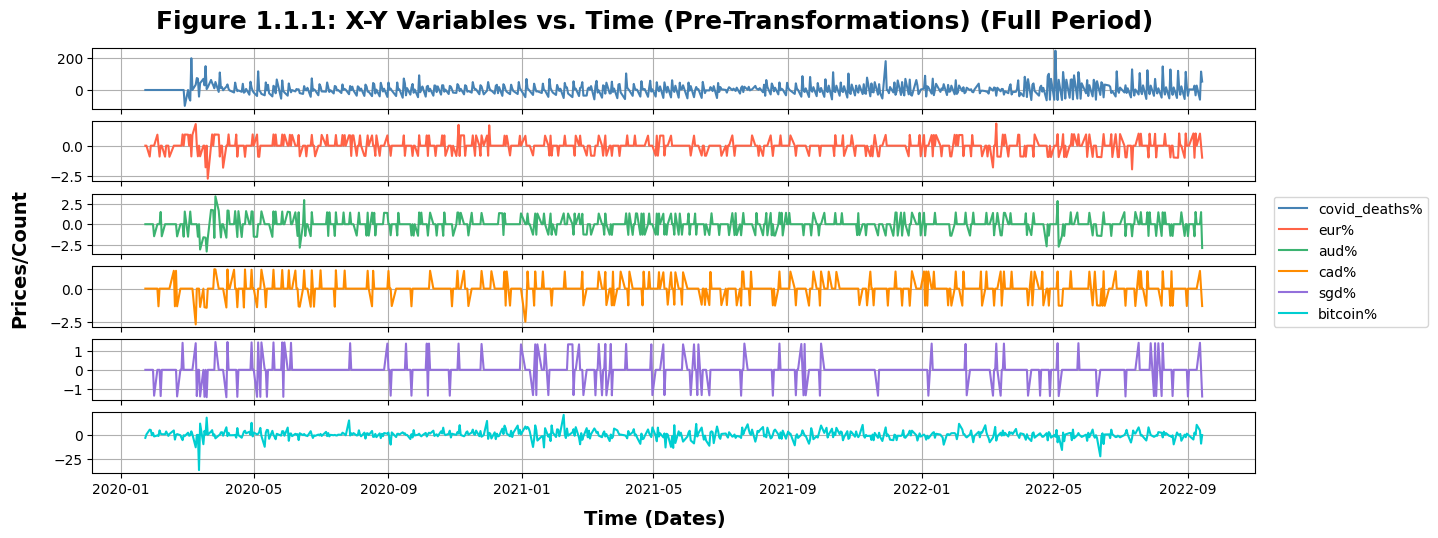

In [16]:
title = f'Figure 1.1.1: X-Y Variables vs. Time (Pre-Transformations) {PRD}'

econ_anlys_vrb.set_coords('1.1.1', PRD, XCAT, YCOL)


matplotlibx.setup_stacked_line_charts(len(ttl_dict))

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices/Count')

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.01)

matplotlibx.set_line_multichart_supylabel_xycoords(0.07, 0.5)


matplotlibx.line_multichart(test_df, title)

## **1.1.2: Transformation: X-Y Variables**

### **The Zivot-Andrews Test: X-Y Variables (Pre-Transformations)**

In [17]:
title = 'Table 1.1.2.1: The Zivot-Andrews Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.zivot_andrews_test_summ_df(ttl_dict, autolag = 'AIC')

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,za_stat,p_value,1%,5%,10%,n_obs,lags_used,break_sq_idx,break_index,break_pct,regr_mthd,autolag,rejects_5pct,stationary
series,,,,,,,,,,,,,,
covid_deaths%,-5.73,0.0038,-5.03,-4.41,-4.14,667,12,100,2020-06-16,15.0%,trend only,AIC,True,stationary with break
eur%,-29.78,0.0008,-5.03,-4.41,-4.14,667,0,100,2020-06-16,15.0%,trend only,AIC,True,stationary with break
aud%,-30.88,0.0008,-5.03,-4.41,-4.14,667,0,100,2020-06-16,15.0%,trend only,AIC,True,stationary with break
cad%,-31.79,0.0007,-5.03,-4.41,-4.14,667,0,100,2020-06-16,15.0%,trend only,AIC,True,stationary with break
sgd%,-10.68,0.0017,-5.03,-4.41,-4.14,667,6,100,2020-06-16,15.0%,trend only,AIC,True,stationary with break
bitcoin%,-6.99,0.0028,-5.03,-4.41,-4.14,667,10,209,2020-11-18,31.3%,trend only,AIC,True,stationary with break


### **The Bai-Perron Test: X-Y Variables (Pre-Transformations)**

In [18]:
title = 'Table 1.1.2.2: The Bai-Perron Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.bai_perron_test_summ_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,n_breaks,break_indices,break_pcts,n_obs,model,model_desc,algorithm
series,,,,,,,
covid_deaths%,5,"[30, 60, 105, 345, 375]","[4.5, 9.0, 15.7, 51.7, 56.2]",667,l2,mean shift detection (changes in level),pelt
eur%,0,n/a,n/a,667,l2,mean shift detection (changes in level),pelt
aud%,1,[40],[6.0],667,l2,mean shift detection (changes in level),pelt
cad%,0,n/a,n/a,667,l2,mean shift detection (changes in level),pelt
sgd%,0,n/a,n/a,667,l2,mean shift detection (changes in level),pelt
bitcoin%,5,"[35, 75, 180, 270, 310]","[5.2, 11.2, 27.0, 40.5, 46.5]",667,l2,mean shift detection (changes in level),pelt


### **The Augmented Dickey-Fuller (ADF) Test: X-Y Variables (Pre-Transformations)**

In [19]:
title = 'Table 1.1.2.3: The Augmented Dickey-Fuller (ADF) Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.adf_test_summ_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,adf_stat,p_value,used_lag,n_obs,1%,5%,10%,margin,regr. mthd.,autolag,stationary
series,,,,,,,,,,,
covid_deaths%,-5.13,0.0000,9,657,-3.44,-2.87,-2.57,-2.26,constant only,BIC,True
eur%,-29.62,0.0000,0,666,-2.57,-1.94,-1.62,-27.68,"no constant, no trend",t-stat,True
aud%,-30.72,0.0000,0,666,-2.57,-1.94,-1.62,-28.78,"no constant, no trend",BIC,True
cad%,-31.71,0.0000,0,666,-2.57,-1.94,-1.62,-29.77,"no constant, no trend",t-stat,True
sgd%,-34.36,0.0000,0,666,-2.57,-1.94,-1.62,-32.42,"no constant, no trend",BIC,True
bitcoin%,-26.89,0.0000,0,666,-2.57,-1.94,-1.62,-24.94,"no constant, no trend",BIC,True


### **The Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test: X-Y Variables (Pre-Transformations)** 

In [20]:
title = 'Table 1.1.2.4: The KPSS Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.kpss_test_summ_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,kpss_stat,p_value,n_lags,n_lags_used,1%,5%,10%,margin,regr. mthd.,stationary
series,,,,,,,,,,
covid_deaths%,0.23,0.1000,None,118,0.74,0.46,0.35,-0.23,constant only,True
eur%,0.03,0.1000,None,4,0.22,0.15,0.12,-0.11,constant and trend,True
aud%,0.15,0.1000,None,4,0.74,0.46,0.35,-0.31,constant only,True
cad%,0.07,0.1000,None,14,0.74,0.46,0.35,-0.39,constant only,True
sgd%,0.22,0.1000,None,15,0.74,0.46,0.35,-0.25,constant only,True
bitcoin%,0.09,0.1000,legacy,20,0.22,0.15,0.12,-0.05,constant and trend,True


### **Cross-Validation for Stationarity - X-Y Variables (Pre-Transformations)** 

In [21]:
title = 'Table 1.1.2.5: The Cross-Validation for Stationarity ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.crss_valid_for_stnry_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,adf_stationary,kpss_stationary,result,conclusion,recommendation
series,,,,,
covid_deaths%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
eur%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
aud%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
cad%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
sgd%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
bitcoin%,True,True,stationary,Both tests agree the series is stationary.,No action needed.


### **Transformations for Stationarity - X-Y Variables**

In [22]:
trns_df = mathx.crct_stnry_df(ttl_dict)

STATIONARY TIME SERIES DETECTED: covid_deaths%.


STATIONARY TIME SERIES DETECTED: eur%.


STATIONARY TIME SERIES DETECTED: aud%.


STATIONARY TIME SERIES DETECTED: cad%.


STATIONARY TIME SERIES DETECTED: sgd%.


STATIONARY TIME SERIES DETECTED: bitcoin%.




### **Cross-Validation for Stationarity - X-Y Variables (Post-Transformations)** 

In [23]:
title = 'Table 1.1.2.6: Corrections for Stationarity ' \
            + f'- {XTTL} vs. {YSBJ} (Post-Transformations) {PRD}'

test_df = mathx.crss_valid_for_stnry_df(trns_df.to_dict(orient = 'series'))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,adf_stationary,kpss_stationary,result,conclusion,recommendation
series,,,,,
covid_deaths%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
eur%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
aud%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
cad%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
sgd%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
bitcoin%,True,True,stationary,Both tests agree the series is stationary.,No action needed.


### **The Zivot-Andrews Test: X-Y Variables (Post-Transformations)**

In [24]:
title = 'Table 1.1.2.7: The Zivot-Andrews Test ' \
            + f'- {XTTL} vs. {YSBJ} (Post-Transformations) {PRD}'

test_df = mathx.zivot_andrews_test_summ_df(trns_df.to_dict(orient = 'series'))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,za_stat,p_value,1%,5%,10%,n_obs,lags_used,break_sq_idx,break_index,break_pct,regr_mthd,autolag,rejects_5pct,stationary
series,,,,,,,,,,,,,,
covid_deaths%,-5.64,0.0039,-5.03,-4.41,-4.14,667,9,100,2020-06-16,15.0%,trend only,BIC,True,stationary with break
eur%,-29.78,0.0008,-5.03,-4.41,-4.14,667,0,100,2020-06-16,15.0%,trend only,BIC,True,stationary with break
aud%,-30.88,0.0008,-5.03,-4.41,-4.14,667,0,100,2020-06-16,15.0%,trend only,BIC,True,stationary with break
cad%,-31.79,0.0007,-5.03,-4.41,-4.14,667,0,100,2020-06-16,15.0%,trend only,BIC,True,stationary with break
sgd%,-34.59,0.0007,-5.03,-4.41,-4.14,667,0,100,2020-06-16,15.0%,trend only,BIC,True,stationary with break
bitcoin%,-27.29,0.0008,-5.03,-4.41,-4.14,667,0,217,2020-12-01,32.5%,trend only,BIC,True,stationary with break


### **The Bai-Perron Test: X-Y Variables (Post-Transformations)**

In [25]:
title = 'Table 1.1.2.8: The Bai-Perron Test ' \
            + f'- {XTTL} vs. {YSBJ} (Post-Transformations) {PRD}'

test_df = mathx.bai_perron_test_summ_df(trns_df.to_dict(orient = 'series'))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,n_breaks,break_indices,break_pcts,n_obs,model,model_desc,algorithm
series,,,,,,,
covid_deaths%,5,"[30, 60, 105, 345, 375]","[4.5, 9.0, 15.7, 51.7, 56.2]",667,l2,mean shift detection (changes in level),pelt
eur%,0,n/a,n/a,667,l2,mean shift detection (changes in level),pelt
aud%,1,[40],[6.0],667,l2,mean shift detection (changes in level),pelt
cad%,0,n/a,n/a,667,l2,mean shift detection (changes in level),pelt
sgd%,0,n/a,n/a,667,l2,mean shift detection (changes in level),pelt
bitcoin%,5,"[35, 75, 180, 270, 310]","[5.2, 11.2, 27.0, 40.5, 46.5]",667,l2,mean shift detection (changes in level),pelt


### **Display X-Y Variables (Post-Transformations)**

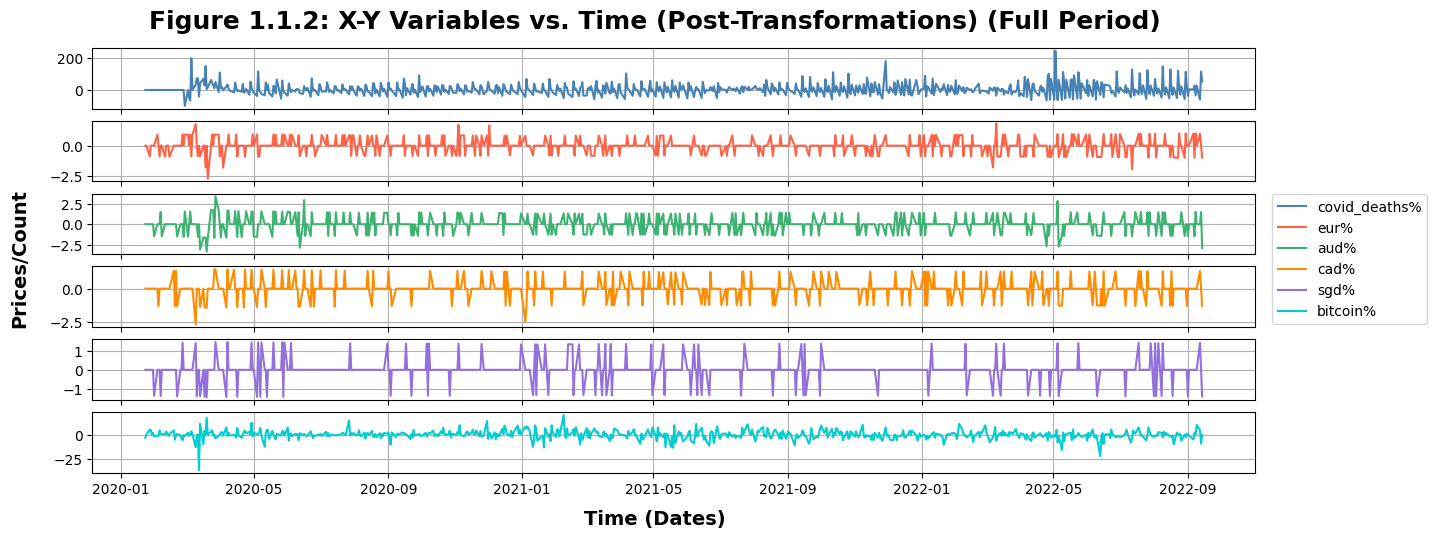

In [26]:
title = f'Figure 1.1.2: X-Y Variables vs. Time (Post-Transformations) {PRD}'

econ_anlys_vrb.set_coords('1.1.2', PRD, XCAT, YCOL)
        

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices/Count')

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.01)

matplotlibx.set_line_multichart_supylabel_xycoords(0.07, 0.5)


matplotlibx.line_multichart(trns_df, title)

### **Assign Data to Series - X-Y Variables (Post-Transformations)**

In [27]:
if YPCT:

    x_series  = trns_df[XCAT]

    y1_series = trns_df[YCAT[Y.Y1.value] + '%']

    y2_series = trns_df[YCAT[Y.Y2.value] + '%']

    y3_series = trns_df[YCAT[Y.Y3.value] + '%']

    y4_series = trns_df[YCAT[Y.Y4.value] + '%']

    y5_series = trns_df[YCAT[Y.Y5.value] + '%']

else:

    x_series  = trns_df[XCAT]

    y1_series = trns_df[YCAT[Y.Y1.value]]

    y2_series = trns_df[YCAT[Y.Y2.value]]

    y3_series = trns_df[YCAT[Y.Y3.value]]

    y4_series = trns_df[YCAT[Y.Y4.value]]

    y5_series = trns_df[YCAT[Y.Y5.value]]

---

## Interpretation: Section 1.1.2 — Stationarity Analysis and Transformations

**The Unique Stationarity Profile of Raw Daily Death Pct Changes.** Unlike the smoothed and cumulative X series used in prior notebooks, the raw daily `covid_deaths` percentage change has a distinctive distributional structure that makes stationarity testing more nuanced. In levels, daily death counts grew dramatically from near zero in January 2020 to peaks in January 2021 (U.S.) and then fluctuated across multiple waves before declining in 2022 — an I(1) or even explosive process. In percentage-change form, the series is nominally stationary but contains: (1) a systematic within-week periodicity from reporting backlogs, (2) wave-onset spikes that can appear as structural breaks in the level of the pct-change process, and (3) prolonged near-zero periods in 2020 Q1 and 2022 H2 that can cause short-memory tests to conflate low-variance regimes with non-stationarity.

**ADF and KPSS Diagnostics.** The ADF test (Table 1.1.2.3) should reject the null of a unit root for the `covid_deaths` pct-change series given its mean-reverting character, but the test statistic may be weaker than for a clean pct-change series because the within-week periodicity introduces autocorrelation at lag 7 that inflates the test's standard errors. The KPSS test (Table 1.1.2.4) tests the null of stationarity; conditional rejection for the death pct-change series would indicate that the periodic wave-onset dynamics are sufficiently persistent to resemble a locally integrated process over sub-windows, even though the full-period series is stationary. The cross-validation table (Table 1.1.2.5) synthesizes both tests' verdicts and determines whether additional correction is needed.

**Structural Breaks Across 966 Days.** The Zivot-Andrews test (Table 1.1.2.1) and Bai-Perron test (Table 1.1.2.2) applied over the full 966-day window will detect multiple structural breaks for both X and Y series. For `covid_deaths` pct changes, the most likely break dates are the onset of the Original wave's exponential growth (March 2020), the Alpha/Beta wave surge (winter 2020–21), the Delta wave onset (summer 2021), and the Omicron transition (late November 2021). For exchange rate returns, structural breaks will cluster around the March 2020 crash, the Fed's emergency interventions, and the Fed's 2022 tightening pivot. Crucially, the Bai-Perron structural break dates for X and Y may not coincide — breaks in COVID mortality dynamics and breaks in currency markets occur at different points — and the post-transformation Bai-Perron results (Table 1.1.2.8) confirm whether any residual break structure persists after stationarity correction. Figure 1.1.2 will show all six post-transformation series spanning the full 966-day window, providing the most temporally comprehensive visualization in the project.

**Practical Consequence for Downstream Tests.** Because the full period contains three causal regime transitions, any stationarity correction applied by `mathx.crct_stnry_df()` must adequately handle not just the overall integration order but also the structural breaks. A series that passes post-transformation stationarity tests globally (Table 1.1.2.6) may still exhibit local non-stationarity within specific sub-phases, which is a known limitation of full-period analysis that the rolling correlation and lag correlation sections help address through time-varying estimation.

---


## **1.1.3: X vs. Y1**

### **Create DataFrame X vs. Y1**

In [28]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y1.value]: y1_series})

logx.log_write_obj(comp_df)

In [29]:
title = f'Table 1.1.3.1: {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y1.value]: pandasx.fmt_dict['flt_int']})

,covid_deaths%,eur
series,,
2020-01-23,0,0
2020-01-24,0,0
2020-01-27,0,-1
2020-01-28,0,0
2020-01-29,0,0
2020-01-30,0,0
2020-01-31,0,0
2020-02-03,0,1
2020-02-04,0,0


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y1**

In [30]:
title = 'Table 1.1.3.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y1_series, x_series)

corr_method = mathx.find_opt_corr_method(y1_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.01,-0.01,0.02,1.00,"4,890.98",0.00,False,0.50
2,0.02,-0.00,0.03,1.00,"4,886.45",0.84,False,0.92
3,0.02,-0.03,0.04,1.00,"4,888.44",0.47,False,0.73
4,0.02,-0.06,0.08,1.00,"4,888.60",0.44,False,0.72
5,0.02,-0.58,1.12,1.00,"4,886.74",0.78,True,0.89
6,0.03,-0.12,0.21,1.00,"4,888.23",0.51,False,0.75
7,0.03,-62.58,125.11,1.00,"4,888.82",0.40,True,0.70
8,0.03,-320.34,640.09,0.99,"4,889.71",0.24,True,0.61
9,0.04,"-11,435.40","22,868.92",0.77,"4,886.23",0.88,True,0.82
10,0.04,"-49,525.30","99,049.05",0.00,"4,885.57",1.00,True,0.50


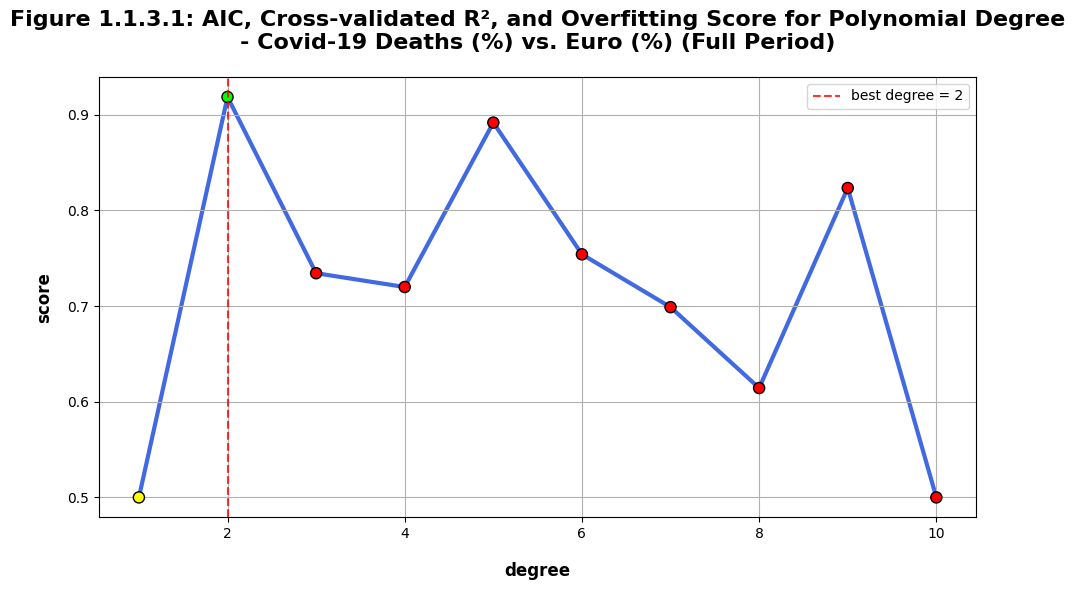

In [31]:
title = 'Figure 1.1.3.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y1**

In [32]:
title = f'Table 1.1.3.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,covid_deaths%,eur
covid_deaths%,1.00,-0.06
eur,-0.06,1.00


### **Scatter Plot: X vs. Y1**

r-value (pearson):	-0.082
r-value (spearman):	-0.055
tau (kendall):		-0.042

p-value (pearson):	0.034
p-value (spearman):	0.153
p-value (kendall):	0.150




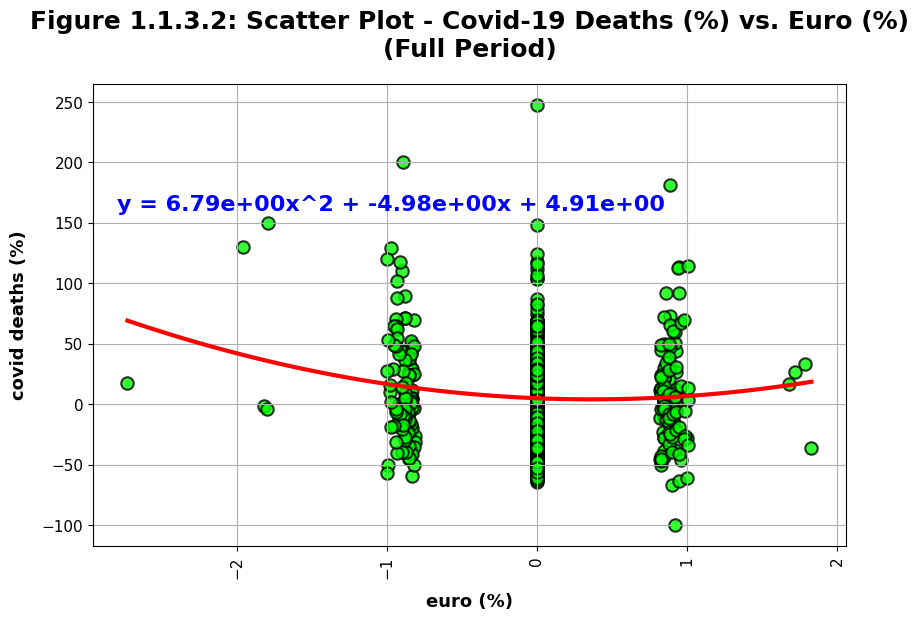

In [33]:
title = 'Figure 1.1.3.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.3.2', PRD, XCAT, YCOL)


matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y1.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y1_series, x_series], title)

### **The Granger Causality Test: X -> Y1**

In [34]:
title = 'Table 1.1.3.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y1.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y1_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y1_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y1_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list = [best_dict]

grngr_nm_list  = [f'{XCAT} -> {YCAT[Y.Y1.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.007267,0.932089,False,False,False,False,high confidence
2,1.701057,0.183290,False,False,False,False,high confidence
3,2.121656,0.096227,False,False,False,False,high confidence
4,1.585036,0.176542,False,False,False,False,high confidence
5,1.472532,0.196680,False,False,False,False,high confidence
6,1.325218,0.243481,False,False,False,False,high confidence
7,1.153469,0.327752,False,False,False,False,high confidence
8,1.227724,0.279867,False,False,False,False,high confidence
9,1.431212,0.170807,False,False,False,False,high confidence


### **The Granger Causality Test: Y1 -> X**

In [35]:
title = 'Table 1.1.3.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y1.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y1_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y1.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.181649,0.670099,False,False,False,False,high confidence
2,2.011806,0.134566,False,False,False,False,high confidence
3,1.572324,0.194825,False,False,False,False,high confidence
4,1.415108,0.227301,False,False,False,False,high confidence
5,0.958046,0.442848,False,False,False,False,high confidence
6,1.419937,0.204345,False,False,False,False,high confidence
7,1.199684,0.300620,False,False,False,False,high confidence
8,1.211265,0.289514,False,False,False,False,high confidence
9,1.132489,0.337120,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y1**

In [36]:
results_dict = mathx.fit_var_or_vecm(x_series, y1_series)

x_y1_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y1.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

COVID_DEATHS% VS. EUR% ANALYSIS

Model selected: VAR.

Series 'x' is stationary (ADF = -5.106945, p = 0.000014).

Series 'y' is stationary (ADF = -29.601738, p = 0.000000).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 6.
AIC = 13, BIC = 6, HQIC = 6, FPE = 13.

VAR(6) fitted.
AIC = 5.716342, BIC = 5.893101.
Stability: UNSTABLE — roots outside unit circle; interpret with caution.

IRF (VAR, 30 periods):
A one-SD shock to x produces a mixed net response in y.
Peak x→y effect at lag 3 (magnitude: -0.001527).
Cumulative x→y response: -0.002623.

FEVD (VAR, horizon = 31):
x shocks explain 1.755720% of y's forecast variance (minimal influence).
y's own shocks explain 98.244280% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y1**

In [37]:
title = 'Table 1.1.3.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    irf_bool = True

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y1.value]} {PRD}\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y1.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,-0.420749,0.000306,0.226307,-0.136302
2,0.019462,0.000288,-1.486368,0.043594
3,0.025771,-0.001527,1.650686,0.014957
4,0.010860,0.000195,-4.829770,-0.013225
5,0.526571,-0.000679,0.179933,-0.023848
6,-0.259195,-0.000182,4.400305,-0.061290
7,-0.037815,0.000413,-3.095609,0.022709
8,0.061099,-0.000915,1.389899,-0.005006


### **Forecast Error Variance Decomposition (FEVD): X vs. Y1**

In [38]:
if irf_bool:
    
    title = 'Table 1.1.3.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

else:

    title = 'Table 1.1.3.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'    

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.004198,0.995802,1.000000,0.000000
1,0.004752,0.995248,0.999985,0.000015
2,0.004903,0.995097,0.999349,0.000651
3,0.011675,0.988325,0.998566,0.001434
4,0.011798,0.988202,0.991914,0.008086
5,0.012981,0.987019,0.993435,0.006565
6,0.012967,0.987033,0.989499,0.010501
7,0.013377,0.986623,0.987426,0.012574
8,0.015680,0.984320,0.987037,0.012963


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y1**

In [39]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y1_series, method = corr_method)

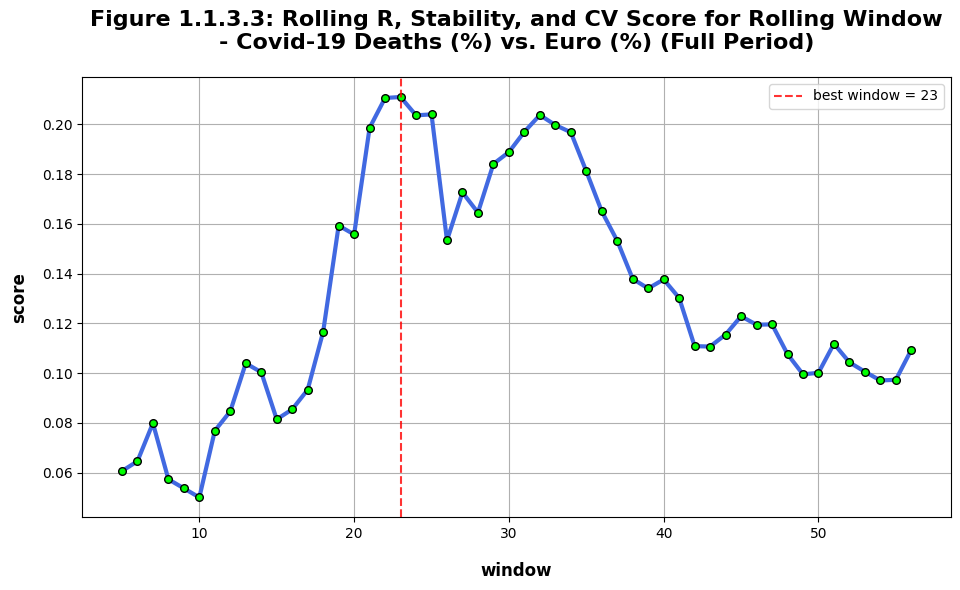

In [40]:
title = 'Figure 1.1.3.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y1**

In [41]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y1_series, best_w, method = corr_method)

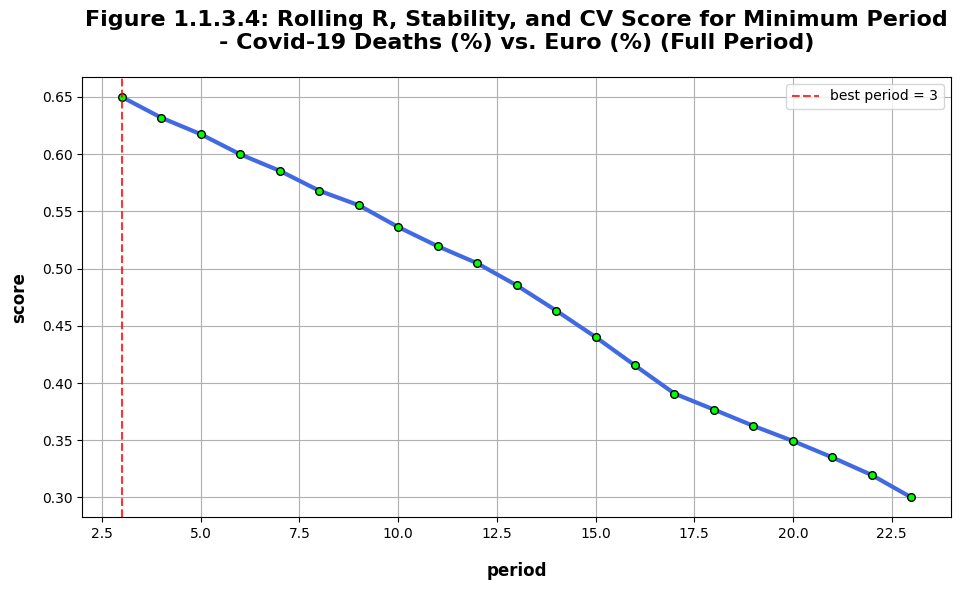

In [42]:
title = 'Figure 1.1.3.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y1**

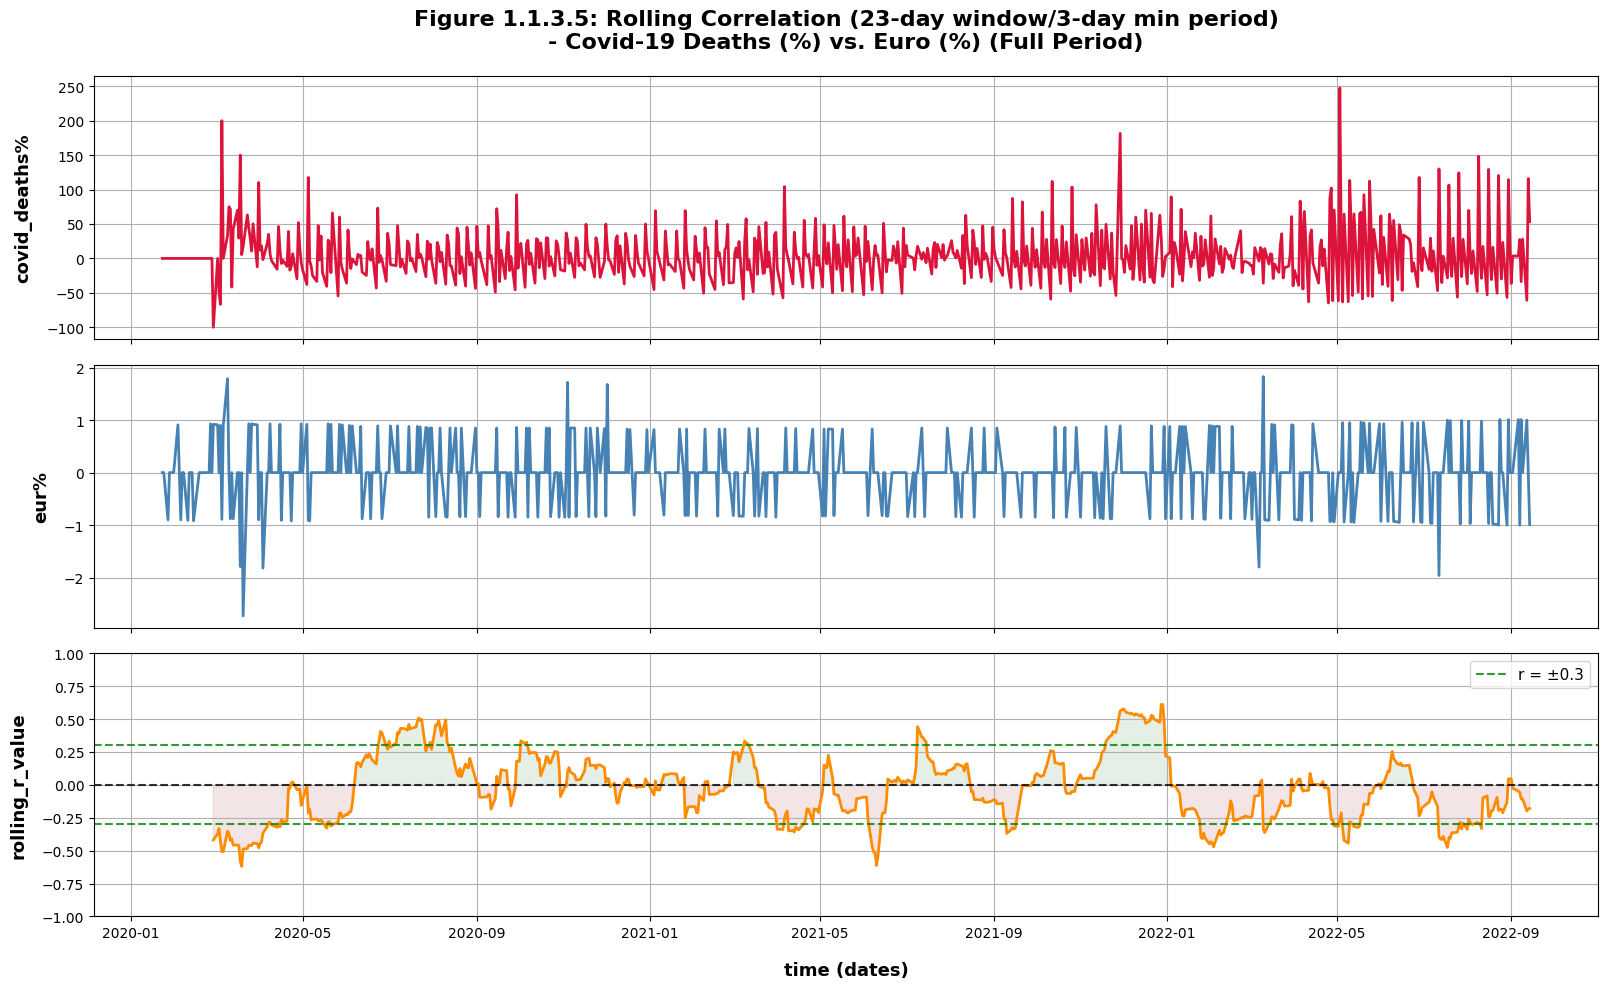

In [43]:
title \
    = f'Figure 1.1.3.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_roll_corr_xylabels('time (dates)', [])

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)


matplotlibx.plot_rolling_corr_lines(x_series, y1_series, title)

### **Lag Correlation: X vs. Y1**

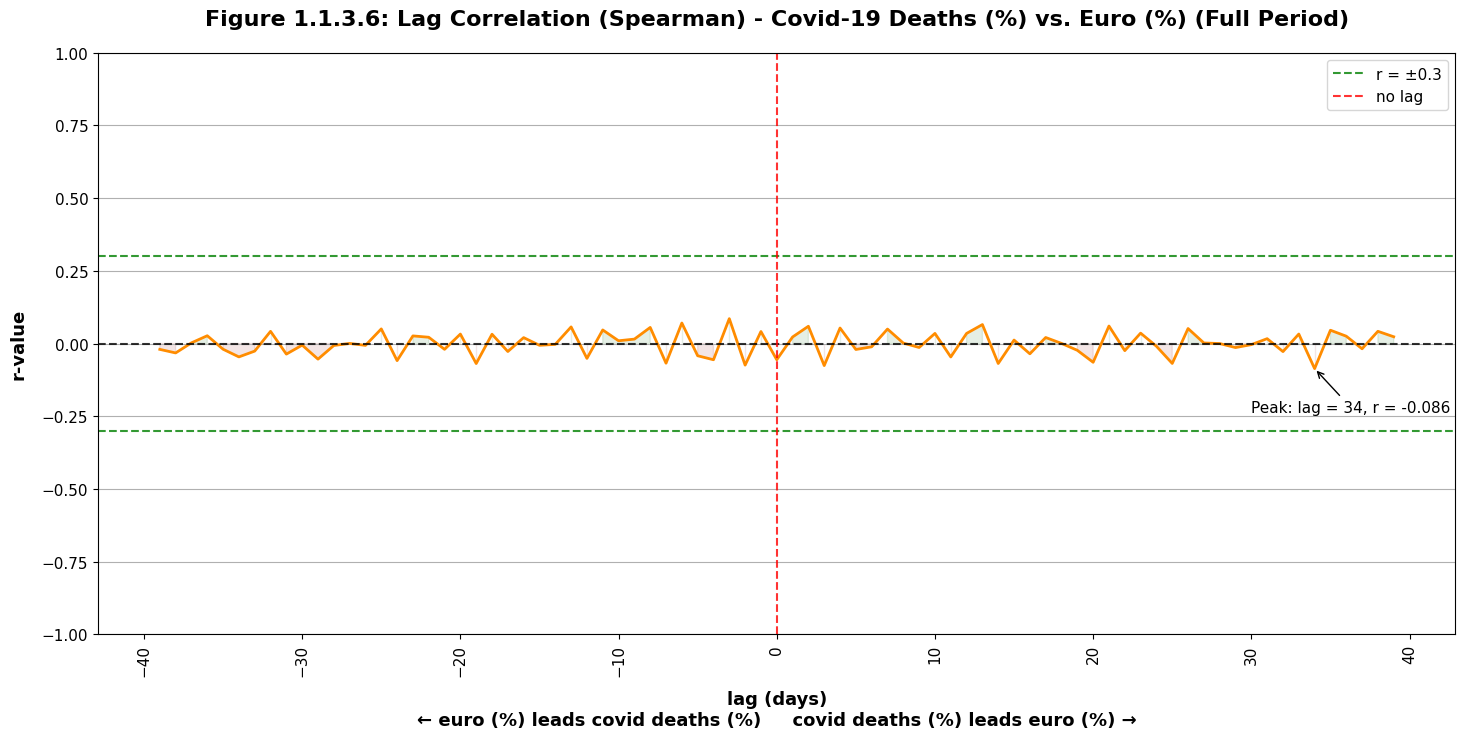

In [44]:
title = f'Figure 1.1.3.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.3.6', PRD, XCAT, YCOL)


v_lag       = int(x_y1_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y1_series, v_lag, g_lag)

max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y1.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y1_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.3 — `covid_deaths` (%) vs. Y1 Exchange Rate Return (%)

**Correlation and Functional Form.** The contemporaneous correlation between raw daily COVID death percentage changes and Y1 exchange rate returns, in the full-period context, measures the average same-day co-movement across all 966 days and all three pandemic phases. Because the raw death series contains the weekly reporting cycle periodicity, the scatter plot (Figure 1.1.3.2) will likely show substantial noise around any underlying relationship — a cloud of observations near the origin (most days, both death changes and exchange rate returns are small) with a thin distribution of outlier observations corresponding to major pandemic events. The polynomial degree selection (Table 1.1.3.2) is particularly important here: a degree higher than 1 for this pair in the full-period context may reflect the nonlinear response of Y1 to extreme COVID death shocks (major wave onsets) rather than a generalizable nonlinear relationship across all observations, and the overfitting score and CV R² comparison will help distinguish between these interpretations.

**Granger Causality.** The Granger test for Y1 (Tables 1.1.3.4 and 1.1.3.5) tests whether the history of raw daily COVID death changes helps predict Y1 returns beyond Y1's own lagged returns. A critical consideration here is the interaction between the weekly reporting periodicity in the X series and the optimal lag selected by `mathx.find_optimal_granger_lag()`. If the optimal lag is a multiple of 7 (7, 14, or 21 days), it would indicate that the Granger test is detecting the weekly death reporting cycle as a predictive signal for exchange rates rather than the genuine epidemiological signal — a form of spurious periodicity detection. A non-multiple-of-7 optimal lag is more consistent with genuine COVID → currency causality. The reverse direction (Y1→X) is expected to be non-significant: currency returns should not predict future COVID deaths.

**VAR/VECM Dynamics.** With 966 observations, the VAR model estimated for Y1 has considerably more power than the phase-specific analyses, which allows for longer optimal lag lengths without the estimation uncertainty that constrained the 292-day Recovery window. The IRF for Y1 quantifies the average dynamic response of this currency to a one-standard-deviation COVID death shock across the full period. Because the true causal relationship changed in direction or magnitude across phases, this full-period IRF represents a weighted average response rather than the response of any specific phase — a limitation that the rolling correlation analysis complements by showing how the relationship varied over time. The FEVD X-share for Y1 is the most directly interpretable metric: what fraction of Y1's total daily return variance, across all 966 days, is attributable to COVID death shocks?

**Rolling and Lag Correlations.** The rolling correlation for Y1 (Figure 1.1.3.5) spanning 966 days is the most temporally rich chart in the project, covering all three pandemic phases. The optimal rolling window selected for Y1 will determine how much temporal resolution is preserved: a short window (30–60 days) will show episode-specific fluctuations in the COVID–Y1 relationship with high resolution, while a long window (90–180 days) will provide smoother, more stable estimates that better represent phase-level dynamics. The sign and magnitude pattern across the three phases — initial strong relationship during the shock, possible attenuation during adaptation, and any Recovery-period behavior — provides the visual narrative for how the COVID → currency relationship evolved for Y1 across the full pandemic timeline.

---


## **1.1.4: X vs. Y2**

### **Create DataFrame X vs. Y2**

In [45]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y2.value]: y2_series})

logx.log_write_obj(comp_df)

In [46]:
title = f'Table 1.1.4.1: {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y2.value]: pandasx.fmt_dict['flt_int']})

,covid_deaths%,aud
series,,
2020-01-23,0,0
2020-01-24,0,0
2020-01-27,0,0
2020-01-28,0,0
2020-01-29,0,0
2020-01-30,0,0
2020-01-31,0,-1
2020-02-03,0,0
2020-02-04,0,0


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y2**

In [47]:
title = 'Table 1.1.4.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y2_series, x_series)

corr_method = mathx.find_opt_corr_method(y2_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.00,-0.01,0.01,1.00,"4,895.47",1.00,False,1.00
2,0.00,-0.02,0.00,1.00,"4,897.29",0.81,False,0.91
3,0.00,-0.04,0.05,1.00,"4,899.26",0.61,False,0.80
4,0.00,-0.06,0.08,1.00,"4,900.75",0.45,False,0.73
5,0.00,-0.09,0.15,1.00,"4,901.35",0.39,False,0.70
6,0.00,-0.11,0.18,1.00,"4,903.16",0.21,False,0.60
7,0.00,-20.48,40.92,1.00,"4,905.16",0.00,True,0.50
8,0.01,"-2,642.57","5,285.10",0.99,"4,904.42",0.08,True,0.53
9,0.01,"-1,564.17","3,128.30",0.99,"4,903.89",0.13,True,0.56
10,0.02,"-189,631.71","379,263.34",0.00,"4,902.09",0.32,True,0.16


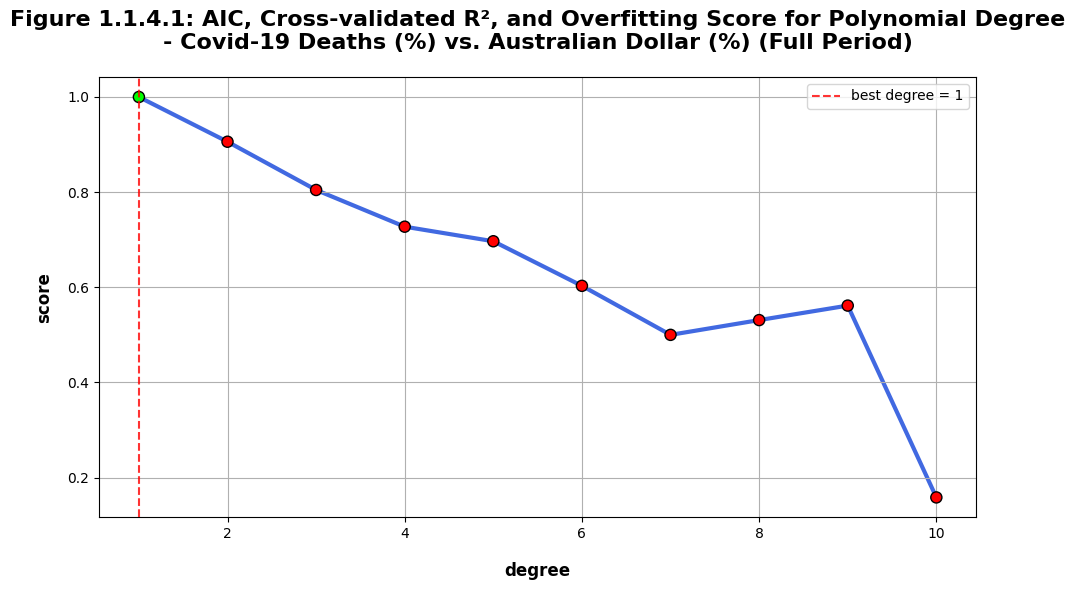

In [48]:
title = 'Figure 1.1.4.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y2**

In [49]:
title = f'Table 1.1.4.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,covid_deaths%,aud
covid_deaths%,1.00,0.01
aud,0.01,1.00


### **Scatter Plot: X vs. Y2**

r-value (pearson):	-0.002
r-value (spearman):	0.011
tau (kendall):		0.008

p-value (pearson):	0.954
p-value (spearman):	0.775
p-value (kendall):	0.783




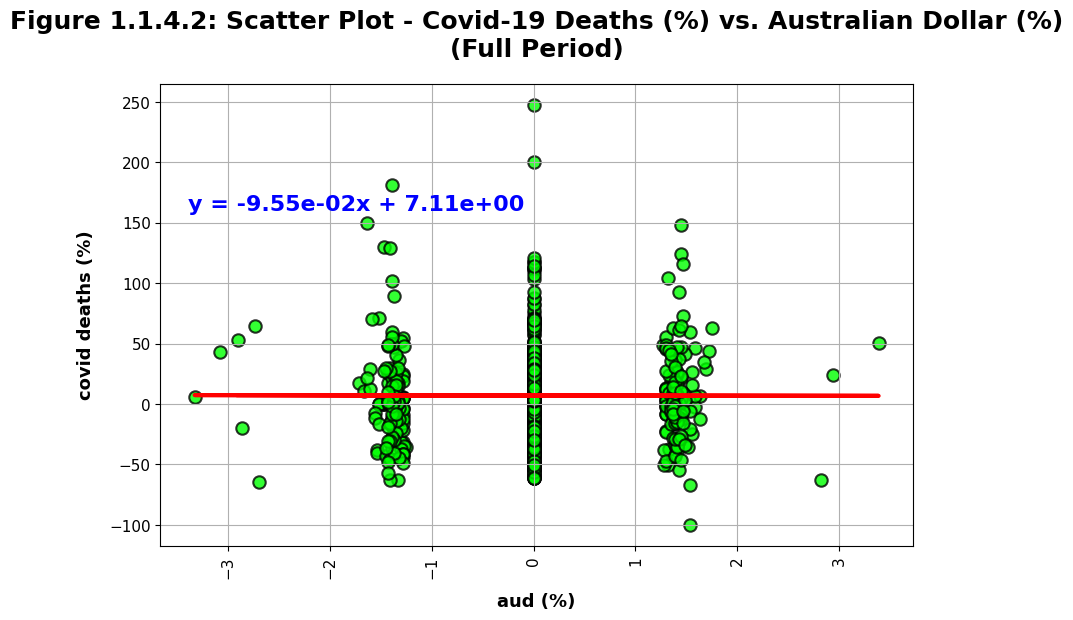

In [50]:
title = 'Figure 1.1.4.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.4.2', PRD, XCAT, YCOL)


matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y2.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y2_series, x_series], title)

### **The Granger Causality Test: X -> Y2**

In [51]:
title = 'Table 1.1.4.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y2.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y2_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y2_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y2_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y2.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,5.078136,0.024555,True,True,True,True,high confidence


### **The Granger Causality Test: Y2 -> X**

In [52]:
title = 'Table 1.1.4.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y2.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y2_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y2.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.149740,0.698908,False,False,False,False,high confidence
2,1.698896,0.183684,False,False,False,False,high confidence
3,1.223844,0.300095,False,False,False,False,high confidence
4,1.667917,0.155701,False,False,False,False,high confidence
5,0.955808,0.444266,False,False,False,False,high confidence
6,0.754461,0.606016,False,False,False,False,high confidence
7,1.095598,0.364142,False,False,False,False,high confidence
8,1.122023,0.346058,False,False,False,False,high confidence
9,1.234797,0.270412,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y2**

In [53]:
results_dict = mathx.fit_var_or_vecm(x_series, y2_series)

x_y2_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y2.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

COVID_DEATHS% VS. AUD% ANALYSIS

Model selected: VAR.

Series 'x' is stationary (ADF = -5.106945, p = 0.000014).

Series 'y' is stationary (ADF = -30.701559, p = 0.000000).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 5.
AIC = 14, BIC = 5, HQIC = 10, FPE = 14.

VAR(5) fitted.
AIC = 6.700486, BIC = 6.849876.
Stability: UNSTABLE — roots outside unit circle; interpret with caution.

IRF (VAR, 30 periods):
A one-SD shock to x produces a mixed net response in y.
Peak x→y effect at lag 1 (magnitude: -0.002430).
Cumulative x→y response: -0.006890.

FEVD (VAR, horizon = 31):
x shocks explain 1.777826% of y's forecast variance (minimal influence).
y's own shocks explain 98.222174% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y2**

In [54]:
title = 'Table 1.1.4.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y2.value]} {PRD}\n')

except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y2.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,-0.341114,-0.002430,-0.673540,-0.182339
2,-0.047874,0.000827,-0.941550,0.043941
3,0.031017,-0.002267,-0.055123,-0.009126
4,-0.009756,-0.001049,-1.125241,-0.009825
5,0.487647,-0.000375,-1.712777,-0.021685
6,-0.318244,-0.000519,0.889111,0.017034
7,0.007485,0.000679,-0.482273,-0.001816
8,0.050845,-0.001091,0.124700,0.008375


### **Forecast Error Variance Decomposition (FEVD): X vs. Y2**

In [55]:
if irf_bool:
    
    title = 'Table 1.1.4.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

else:

    title = 'Table 1.1.4.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}') 

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.001121,0.998879,1.000000,0.000000
1,0.006817,0.993183,0.999655,0.000345
2,0.007493,0.992507,0.998983,0.001017
3,0.013171,0.986829,0.998982,0.001018
4,0.014364,0.985636,0.998024,0.001976
5,0.014496,0.985504,0.996547,0.003453
6,0.014808,0.985192,0.996330,0.003670
7,0.015319,0.984681,0.996196,0.003804
8,0.016648,0.983352,0.996194,0.003806


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y2**

In [56]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y2_series, method = corr_method)

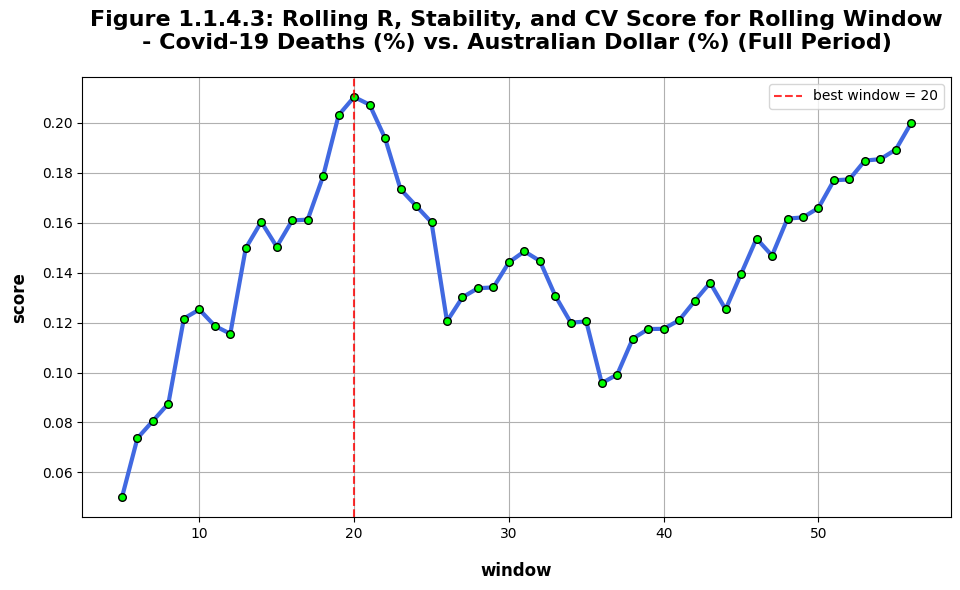

In [57]:
title = 'Figure 1.1.4.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y2**

In [58]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y2_series, best_w, method = corr_method)

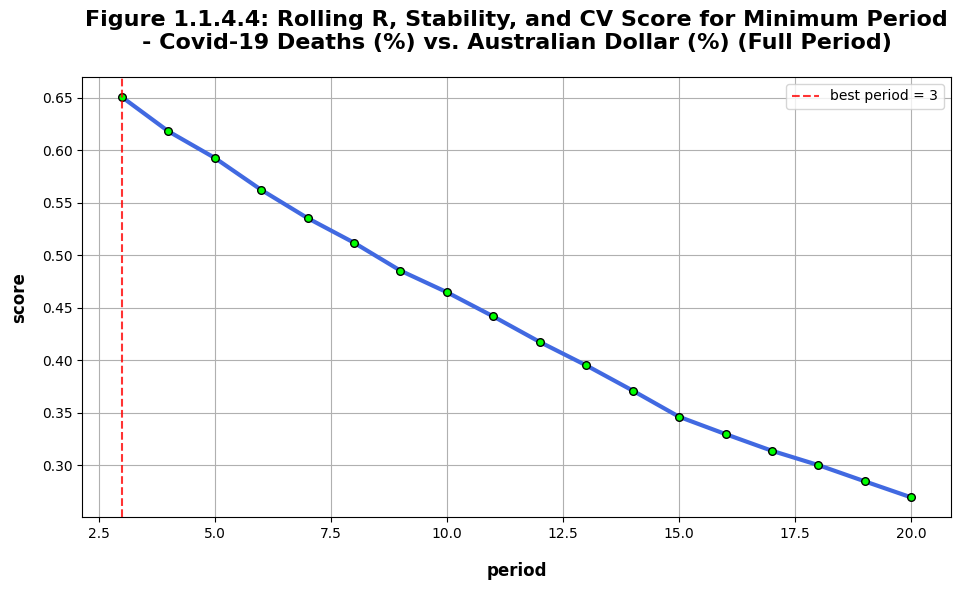

In [59]:
title = 'Figure 1.1.4.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y2**

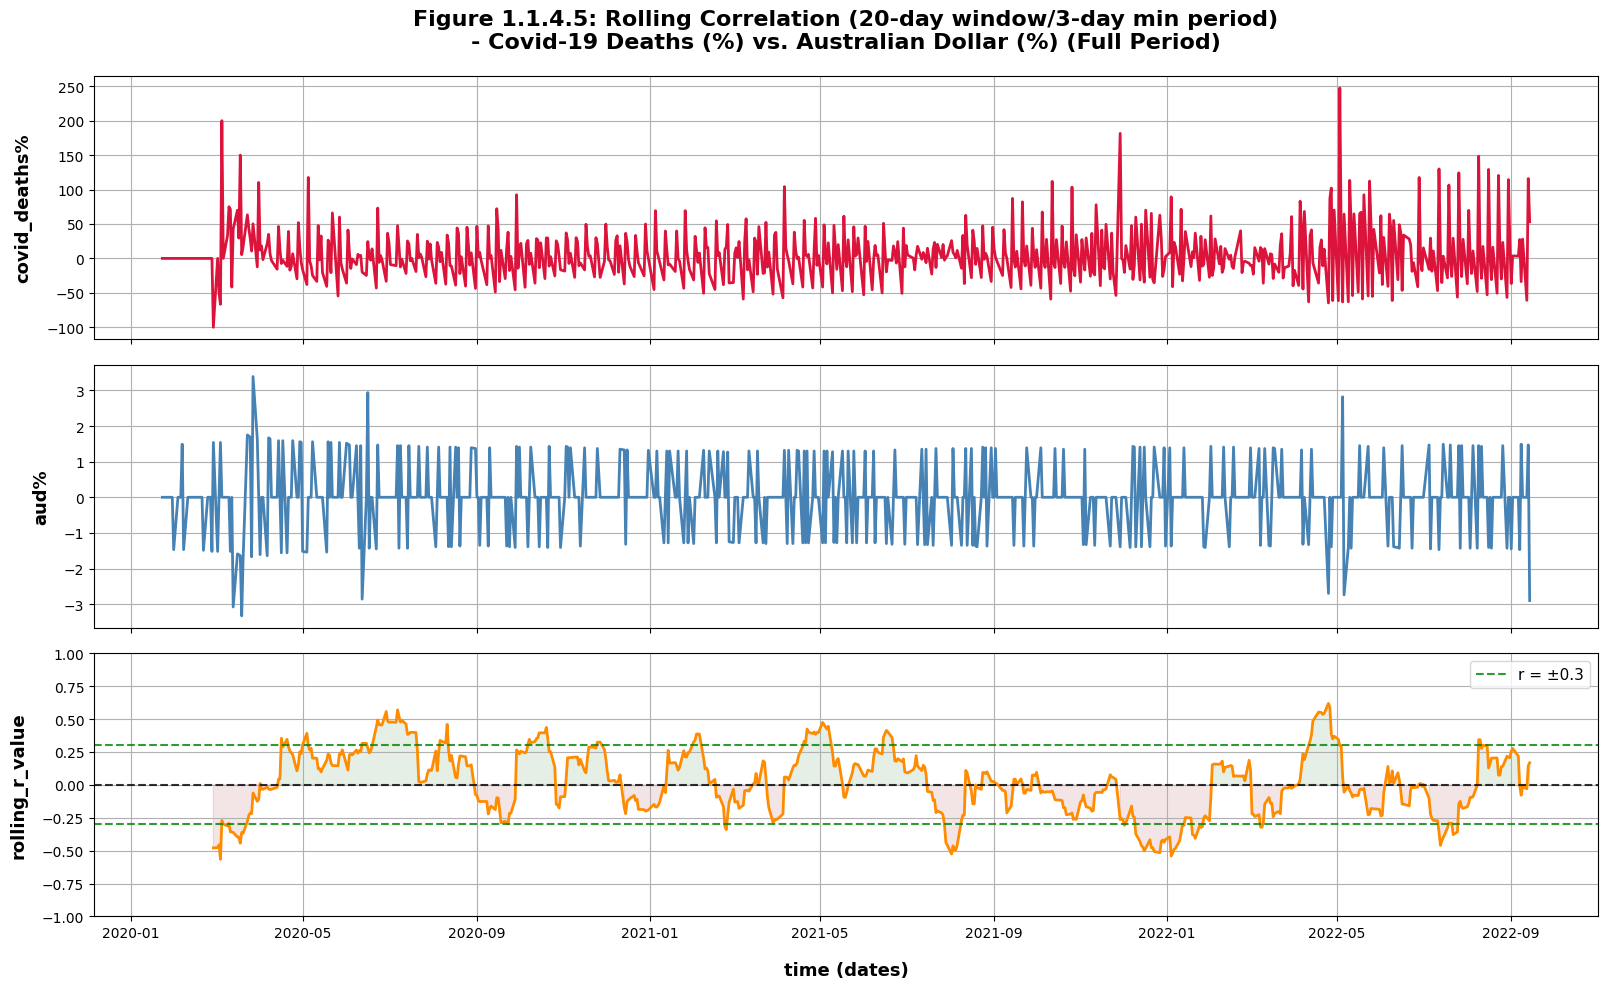

In [60]:
title \
    = f'Figure 1.1.4.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y2_series, title)

### **Lag Correlation: X vs. Y2**

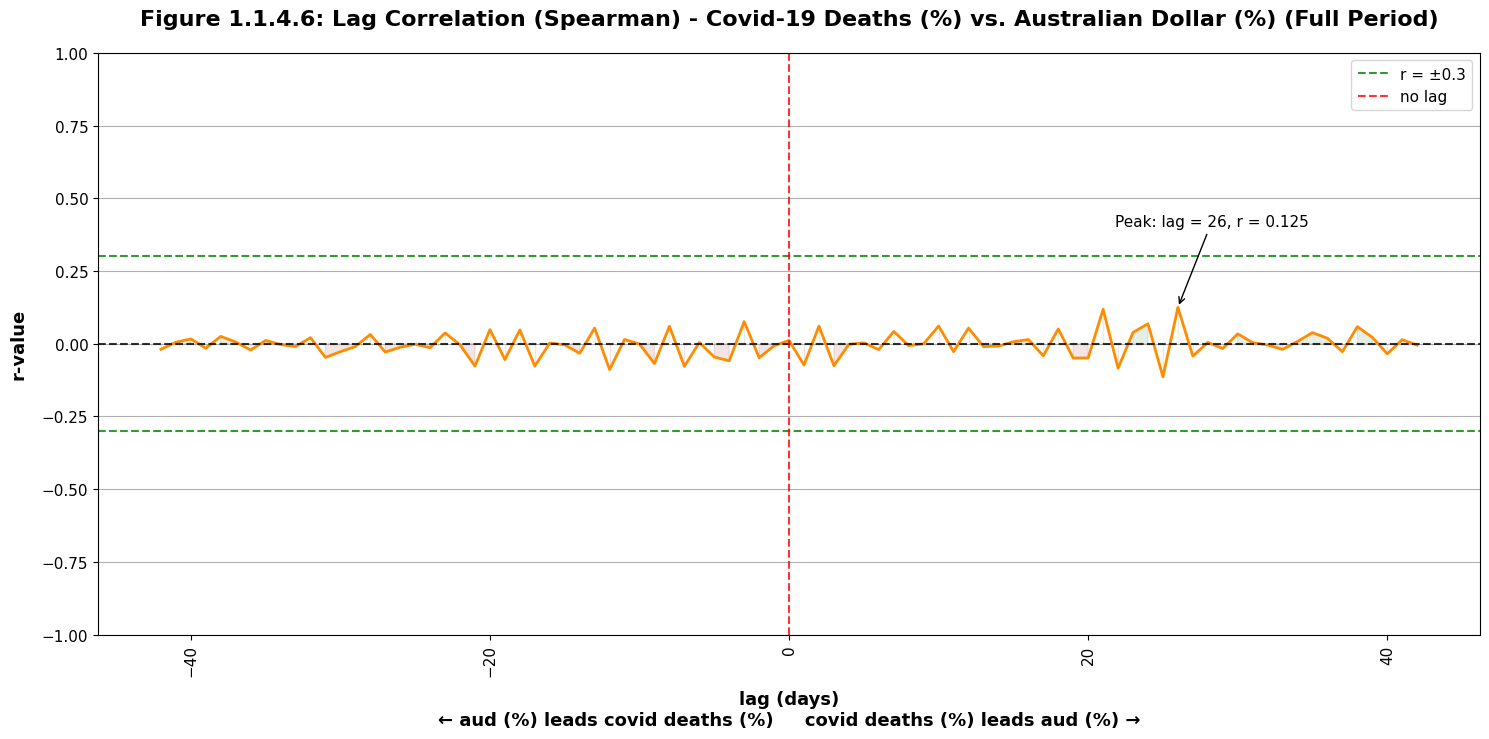

In [61]:
title = f'Figure 1.1.4.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.4.6', PRD, XCAT, YCOL)


v_lag       = int(x_y2_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y2_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y2.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y2_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.4 — `covid_deaths` (%) vs. Y2 Exchange Rate Return (%)

**Correlation and Functional Form.** Y2's correlation with raw COVID death percentage changes provides the first cross-currency comparison in the full-period context. A meaningful difference in correlation magnitude between Y1 and Y2 reflects a genuine difference in these currencies' structural sensitivity to pandemic mortality data across the full 966-day window — not a phase-specific finding but an average characteristic of the full period. In the full-period context, the correlation is pulled toward the time-weighted average causal relationship across all three phases. If Y1 had a strong Initial Shock relationship that subsequently reversed, while Y2 had a weaker but more consistent full-period relationship, Y2 may have a higher full-period correlation despite a lower peak-phase correlation.

**Granger Causality.** The Granger test comparison between Y1 and Y2 in the full-period setting is more statistically powerful than in any phase-specific analysis due to the larger sample. With 966 observations minus lags, even a very weak causal relationship (explaining 1–2% of variance) may produce a significant F-statistic. This means that interpreting the significance threshold alone is insufficient — the F-statistic magnitude, the FEVD X-share, and the lag correlation `r_improvement` together constitute the evidence for a practically meaningful relationship, not just a statistically detectable one. The relative ordering of Y1 and Y2 F-statistics across the X→Y direction reveals which currency's returns were more predictable from the raw COVID death signal.

**VAR/VECM Dynamics.** With the full 966-day window, the VAR/VECM model for Y2 has enough observations to support longer lag lengths without parameter proliferation, which means the model can capture more of the delayed transmission dynamics between COVID deaths and Y2 returns. The optimal lag for Y2 — determined by `mathx.find_var_or_vecm_results()` — reflects how many days of COVID death history are informative about Y2's next-day return. A longer optimal lag for Y2 than Y1 would indicate that this currency incorporates COVID information more slowly, potentially through monetary policy or current account channels rather than through direct investor sentiment flows. The FEVD X-share for Y2, placed alongside Y1's, begins building the cross-currency picture that Table 1.1.8.5 will complete.

**Rolling and Lag Correlations.** The 966-day rolling correlation chart for Y2 (Figure 1.1.4.5) enables a direct visual comparison of how this currency's COVID sensitivity evolved relative to Y1 across the full pandemic timeline. Currencies that show synchronized rolling correlation patterns — both strengthening during the same pandemic episodes and weakening simultaneously — are likely driven by the same underlying COVID transmission channel (e.g., global risk sentiment). Currencies that show divergent rolling correlation patterns — one strengthening while another weakens — are driven by different channels and represent genuinely distinct causal relationships with COVID mortality data, making their individual analysis more informative.

---


## **1.1.5: X vs. Y3**

### **Create DataFrame X vs. Y3**

In [62]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y3.value]: y3_series})

logx.log_write_obj(comp_df)

In [63]:
title = f'Table 1.1.5.1: {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y3.value]: pandasx.fmt_dict['flt_int']})

,covid_deaths%,cad
series,,
2020-01-23,0,0
2020-01-24,0,0
2020-01-27,0,0
2020-01-28,0,0
2020-01-29,0,0
2020-01-30,0,0
2020-01-31,0,0
2020-02-03,0,0
2020-02-04,0,-1


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y3**

In [64]:
title = 'Table 1.1.5.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y3_series, x_series)

corr_method = mathx.find_opt_corr_method(y3_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.00,-0.01,0.01,1.00,"4,894.84",1.00,False,1.00
2,0.00,-0.02,0.02,1.00,"4,895.92",0.87,False,0.94
3,0.00,-0.02,0.02,1.00,"4,896.82",0.77,False,0.88
4,0.01,-0.02,0.01,1.00,"4,896.43",0.81,False,0.91
5,0.01,-0.07,0.08,1.00,"4,898.28",0.60,False,0.80
6,0.01,-0.30,0.39,1.00,"4,898.95",0.52,True,0.76
7,0.01,-438.98,877.46,0.99,"4,899.53",0.45,True,0.72
8,0.01,"-3,609.57","7,016.94",0.89,"4,901.53",0.22,True,0.55
9,0.01,"-9,760.99","13,832.65",0.69,"4,903.37",0.00,True,0.34
10,0.02,"-31,462.43","59,732.71",0.00,"4,902.14",0.14,True,0.07


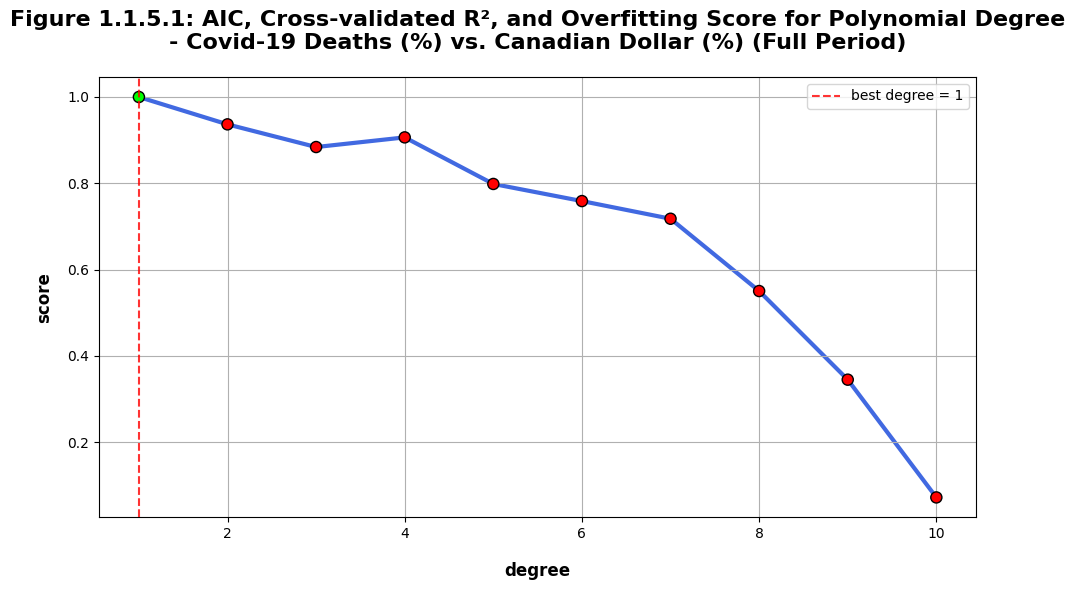

In [65]:
title = 'Figure 1.1.5.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y3**

In [66]:
title = f'Table 1.1.5.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,covid_deaths%,cad
covid_deaths%,1.00,-0.03
cad,-0.03,1.00


### **Scatter Plot: X vs. Y3**

r-value (pearson):	-0.031
r-value (spearman):	-0.027
tau (kendall):		-0.021

p-value (pearson):	0.426
p-value (spearman):	0.482
p-value (kendall):	0.480




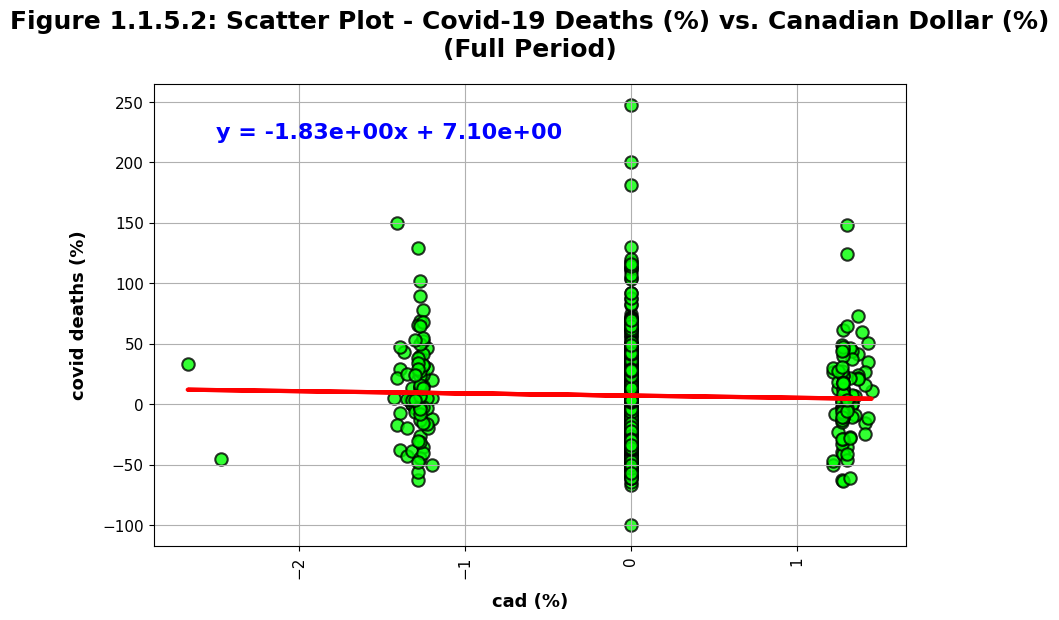

In [67]:
title = 'Figure 1.1.5.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.5.2', PRD, XCAT, YCOL)


matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y3.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y3_series, x_series], title)

### **The Granger Causality Test: X -> Y3**

In [68]:
title = 'Table 1.1.5.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y3.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y3_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y3_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y3_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y3.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.399269,0.527685,False,False,False,False,high confidence
2,2.032655,0.131807,False,False,False,False,high confidence
3,2.349410,0.071389,False,False,False,False,high confidence
4,2.010398,0.091404,False,False,False,False,high confidence
5,1.802063,0.110303,False,False,False,False,high confidence
6,1.484384,0.180854,False,False,False,False,high confidence
7,1.959093,0.058321,False,False,False,False,high confidence
8,2.128693,0.031320,True,True,True,True,high confidence


### **The Granger Causality Test: Y3 -> X**

In [69]:
title = 'Table 1.1.5.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y3.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y3_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y3.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,2.013263,0.156400,False,False,False,False,high confidence
2,1.861149,0.156309,False,False,False,False,high confidence
3,1.754396,0.154632,False,False,False,False,high confidence
4,2.210183,0.066435,False,False,False,False,high confidence
5,1.039182,0.393465,False,False,False,False,high confidence
6,1.034226,0.401720,False,False,False,False,high confidence
7,1.156867,0.325698,False,False,False,False,high confidence
8,1.104126,0.358256,False,False,False,False,high confidence
9,1.212439,0.284100,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y3**

In [70]:
results_dict = mathx.fit_var_or_vecm(x_series, y3_series)

x_y3_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y3.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

COVID_DEATHS% VS. CAD% ANALYSIS

Model selected: VAR.

Series 'x' is stationary (ADF = -5.106945, p = 0.000014).

Series 'y' is stationary (ADF = -31.686112, p = 0.000000).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 5.
AIC = 10, BIC = 5, HQIC = 10, FPE = 10.

VAR(5) fitted.
AIC = 6.034620, BIC = 6.184010.
Stability: UNSTABLE — roots outside unit circle; interpret with caution.

IRF (VAR, 30 periods):
A one-SD shock to x produces a mixed net response in y.
Peak x→y effect at lag 2 (magnitude: -0.001833).
Cumulative x→y response: -0.004042.

FEVD (VAR, horizon = 31):
x shocks explain 1.300536% of y's forecast variance (minimal influence).
y's own shocks explain 98.699464% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y3**

In [71]:
title = 'Table 1.1.5.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y3.value]} {PRD}\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y3.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,-0.339473,-0.000587,-3.708567,-0.222026
2,-0.045750,-0.001833,-0.559794,0.000651
3,0.034709,-0.000439,1.595253,-0.030716
4,-0.009374,0.000090,-1.087216,-0.037352
5,0.486236,-0.000369,0.486283,0.029710
6,-0.322988,0.000182,-1.795505,-0.001647
7,0.008984,-0.000847,0.215499,0.003617
8,0.047352,0.000067,1.022066,0.002502


### **Forecast Error Variance Decomposition (FEVD): X vs. Y3**

In [72]:
if irf_bool:
    
    title = 'Table 1.1.5.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

else:

    title = 'Table 1.1.5.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.002213,0.997787,1.000000,0.000000
1,0.002404,0.997596,0.994628,0.005372
2,0.009648,0.990352,0.994516,0.005484
3,0.009996,0.990004,0.993537,0.006463
4,0.010017,0.989983,0.993081,0.006919
5,0.010347,0.989653,0.994206,0.005794
6,0.010418,0.989582,0.993658,0.006342
7,0.011956,0.988044,0.993644,0.006356
8,0.011965,0.988035,0.993345,0.006655


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y3**

In [73]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y3_series, method = corr_method)

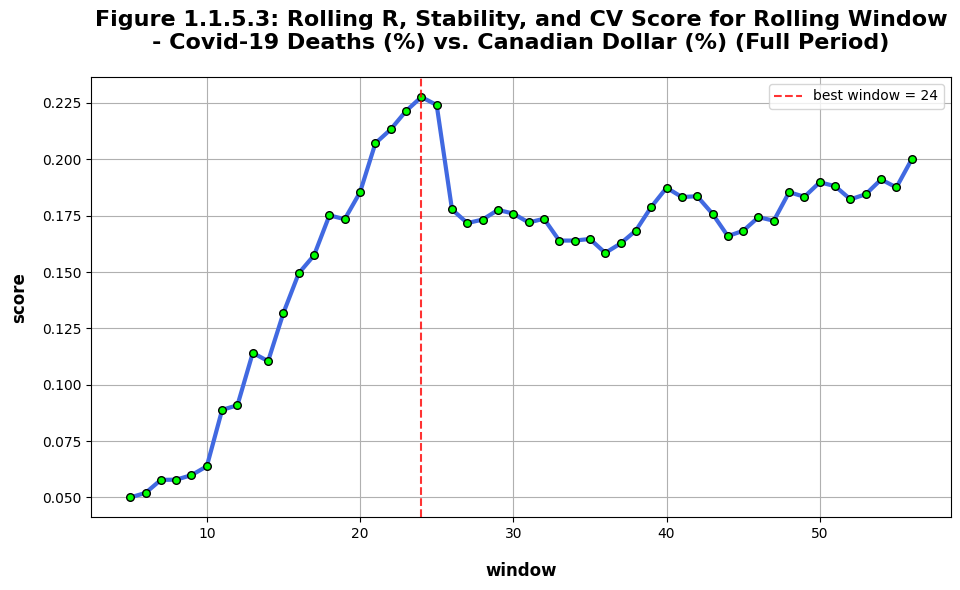

In [74]:
title = 'Figure 1.1.5.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y3**

In [75]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y3_series, best_w, method = corr_method)

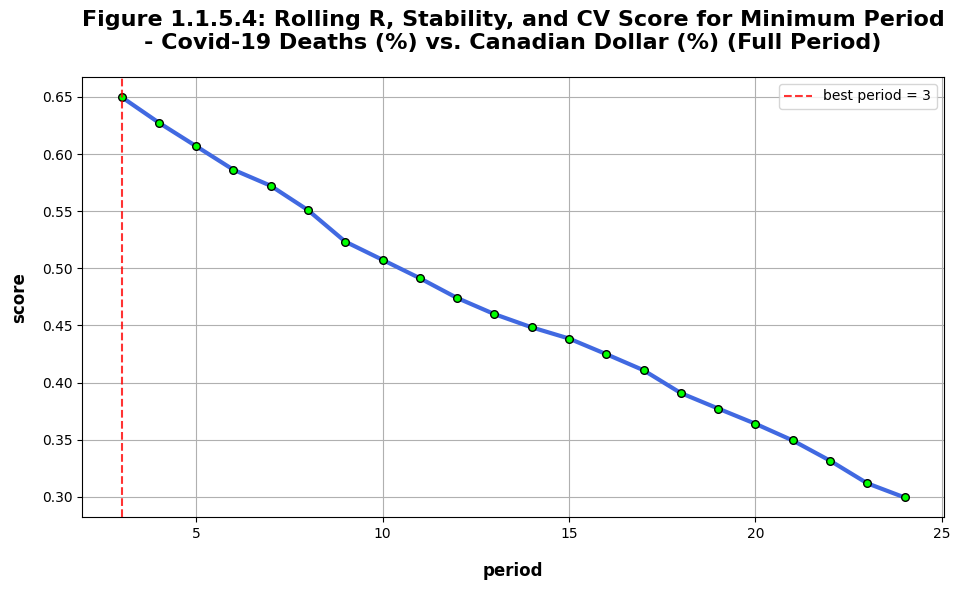

In [76]:
title = 'Figure 1.1.5.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y3**

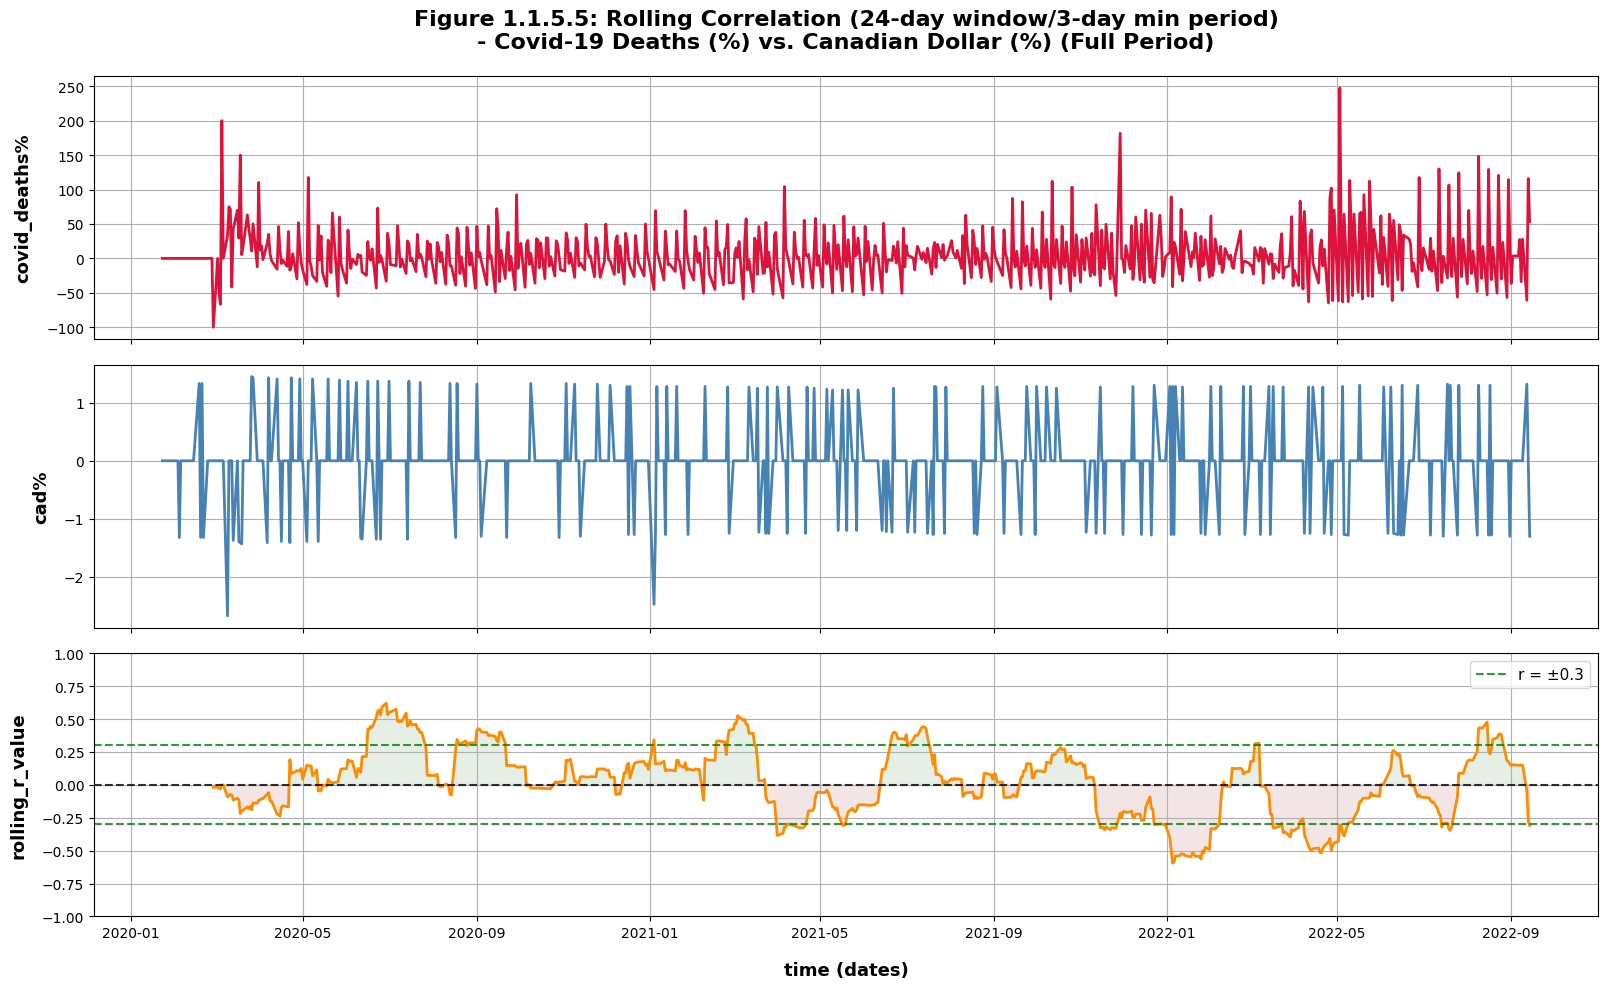

In [77]:
title \
    = f'Figure 1.1.5.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y3_series, title)

### **Lag Correlation: X vs. Y3**

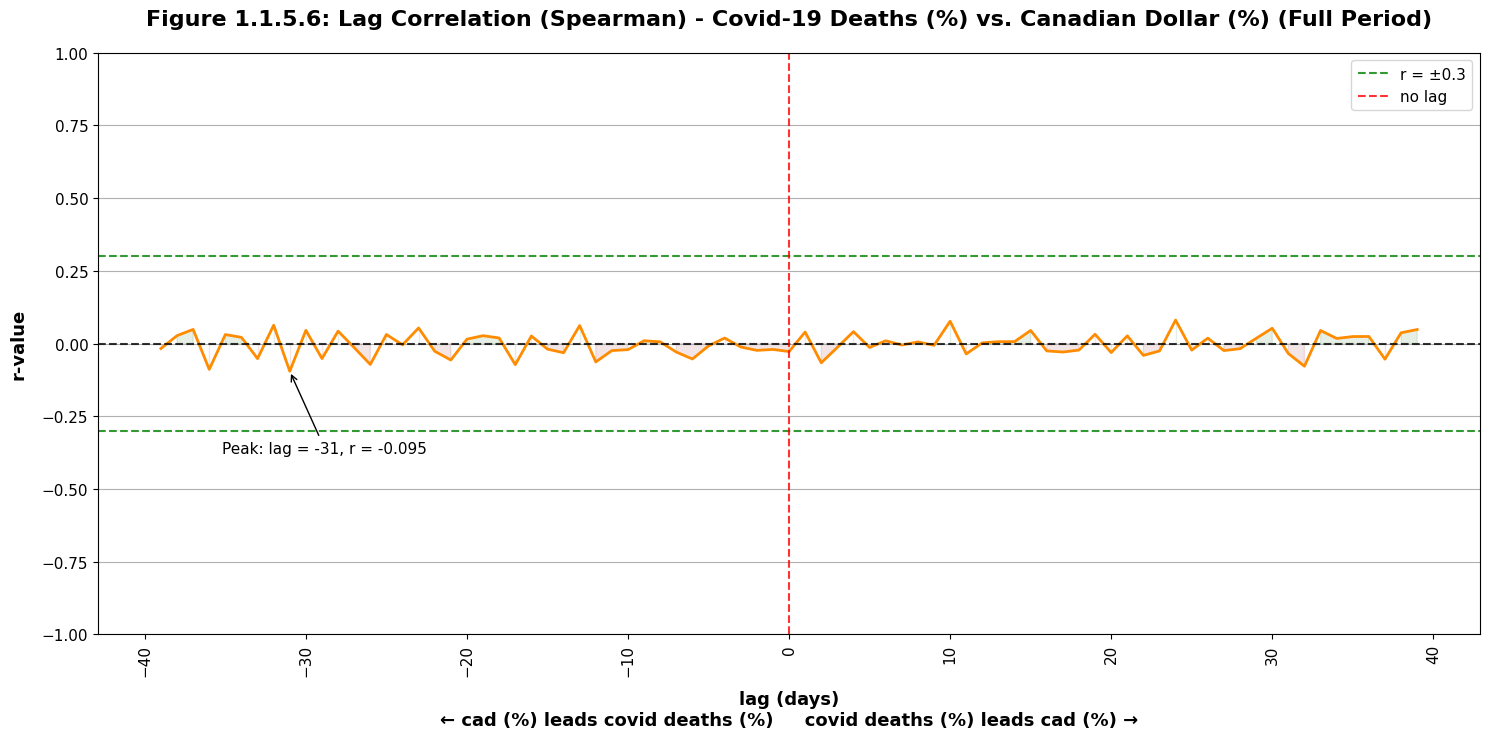

In [78]:
title = f'Figure 1.1.5.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.5.6', PRD, XCAT, YCOL)


v_lag       = int(x_y3_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y3_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y3.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y3_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.5 — `covid_deaths` (%) vs. Y3 Exchange Rate Return (%)

**Correlation and Functional Form.** By the third currency pair, the cross-currency pattern of COVID sensitivity is sufficiently developed to assess whether the exchange rate market shows broad-based or selective COVID signal transmission. Exchange rates are particularly interesting in the full-period context because the sign of the COVID → currency relationship is theoretically currency-specific: currencies of countries with worse relative COVID outcomes should weaken against safe havens, meaning that the X→Y sign depends on which currency is the base and which is the quote in each pair's convention. If Y3's full-period correlation has the opposite sign to Y1 and Y2, it may reflect a different currency convention rather than a different economic channel — a distinction the scatter plot (Figure 1.1.5.2) helps clarify by showing whether the relationship is one of co-movement or counter-movement in the denominated units.

**Granger Causality.** At three currencies analyzed, the full-period Granger pattern becomes statistically interpretable. With the large full-period sample, if all three X→Y tests are significant, it points to a robust, broad-based COVID death → exchange rate causal channel rather than selective or currency-specific sensitivity. The F-statistics' magnitude ranking across Y1, Y2, and Y3 reveals which currency's returns were most efficiently predicted by the raw COVID death signal — and by extension, which currency most directly channels pandemic mortality information into its price. A reversal of the Y→X direction for Y3 (exchange rate returns predicting future COVID deaths) would be an unusual finding in the full-period context, potentially reflecting a coincidental lag structure during one specific phase rather than genuine feedback from currency markets to epidemiology.

**VAR/VECM Dynamics.** The IRF for Y3 contributes a third data point to the cross-currency comparison of impulse response shapes and magnitudes. An important diagnostic in the full-period context is whether Y3's IRF shows a consistent monotone decay profile or an oscillatory, sign-changing response. Oscillatory IRFs in percentage-change VAR models on 966 observations are relatively uncommon and may indicate that the average COVID → Y3 relationship across the full period switched direction between phases — a high-COVID-death sub-period produced one response, while a low-COVID-death sub-period produced the opposite, and the model's averaged-over-time IRF captures the result of these competing dynamics. The FEVD X-share for Y3 places this currency in the cross-currency variance decomposition hierarchy.

**Rolling and Lag Correlations.** The rolling correlation for Y3 (Figure 1.1.5.5), spanning all 966 days, should be read for three specific features: (1) the correlation's sign and magnitude during the Initial Shock (January–June 2020), which represents the period of strongest expected COVID signal; (2) whether the correlation reversed, diminished, or persisted during the Adaptation phase (June 2020–November 2021); and (3) the correlation's behavior during the Recovery phase (November 2021–September 2022), where the Omicron case surge and Fed tightening cycle created two opposing forces. A rolling correlation that remains consistently signed across all three phases — even if the magnitude varies — would be the strongest possible full-period finding for Y3: evidence that the COVID death signal had a directionally stable, if phase-varying, relationship with this currency throughout the entire pandemic.

---


## **1.1.6: X vs. Y4**

### **Create DataFrame X vs. Y4**

In [79]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y4.value]: y4_series})

logx.log_write_obj(comp_df)

In [80]:
title = f'Table 1.1.6.1: {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y4.value]: pandasx.fmt_dict['flt_int']})

,covid_deaths%,sgd
series,,
2020-01-23,0,0
2020-01-24,0,0
2020-01-27,0,0
2020-01-28,0,0
2020-01-29,0,0
2020-01-30,0,0
2020-01-31,0,-1
2020-02-03,0,0
2020-02-04,0,0


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y4**

In [81]:
title = 'Table 1.1.6.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y4_series, x_series)

corr_method = mathx.find_opt_corr_method(y4_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.00,-0.01,0.01,1.00,"4,895.48",0.91,False,0.96
2,0.00,-0.01,0.01,1.00,"4,897.46",0.71,False,0.86
3,0.01,-0.00,0.01,1.00,"4,895.55",0.91,False,0.95
4,0.01,0.00,0.01,1.00,"4,894.64",1.00,False,1.00
5,0.01,-0.02,0.02,1.00,"4,896.63",0.80,False,0.90
6,0.01,-0.05,0.09,1.00,"4,898.16",0.64,False,0.82
7,0.01,-2.02,4.00,0.94,"4,900.16",0.44,True,0.69
8,0.01,-2.02,3.99,0.94,"4,901.11",0.34,True,0.64
9,0.01,-28.05,56.04,0.14,"4,902.50",0.20,True,0.17
10,0.01,-32.80,65.53,0.00,"4,904.45",0.00,True,0.00


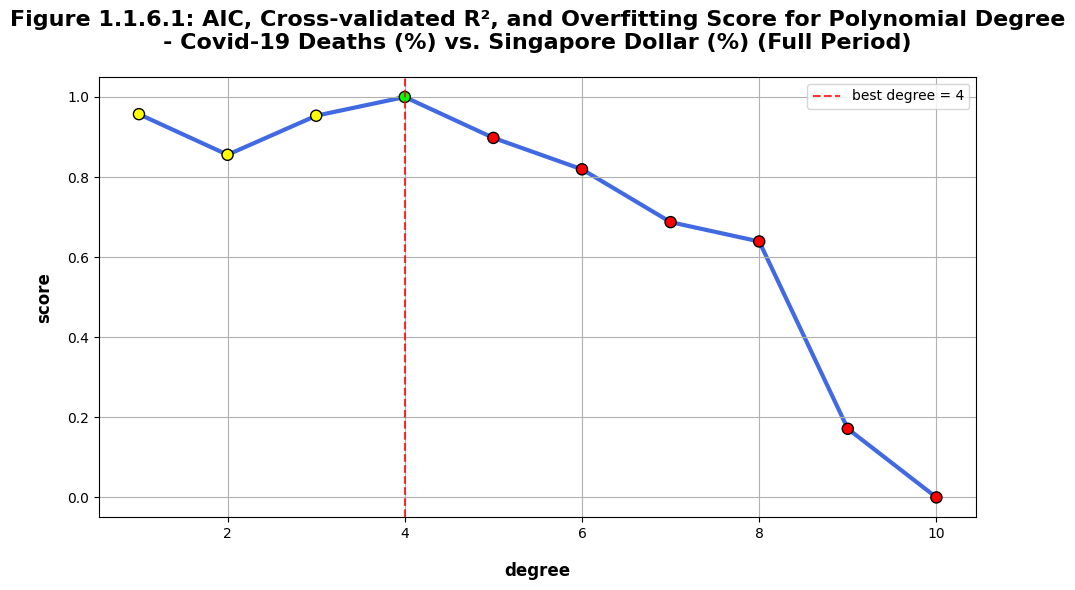

In [82]:
title = 'Figure 1.1.6.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y4**

In [83]:
title = f'Table 1.1.6.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

pandasx.rtn_fmt_tbl (comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,covid_deaths%,sgd
covid_deaths%,1.00,-0.03
sgd,-0.03,1.00


### **Scatter Plot: X vs. Y4**

r-value (pearson):	0.000
r-value (spearman):	-0.029
tau (kendall):		-0.024

p-value (pearson):	0.996
p-value (spearman):	0.452
p-value (kendall):	0.437




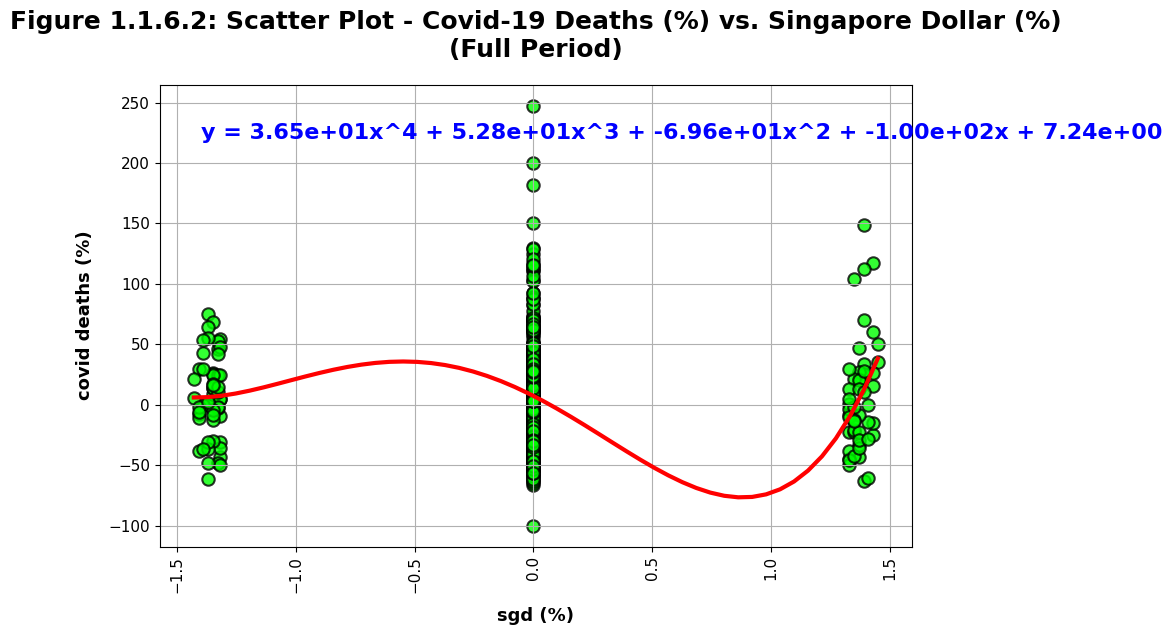

In [84]:
title = 'Figure 1.1.6.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.6.2', PRD, XCAT, YCOL)
            

matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y4.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y4_series, x_series], title)

### **The Granger Causality Test: X -> Y4**

In [85]:
title = 'Table 1.1.6.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y4.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y4_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y4_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y4_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y4.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,1.596386,0.206860,False,False,False,False,high confidence
2,1.277883,0.279315,False,False,False,False,high confidence
3,1.199515,0.309093,False,False,False,False,high confidence
4,1.703283,0.147511,False,False,False,False,high confidence
5,1.326210,0.251075,False,False,False,False,high confidence
6,1.391548,0.215482,False,False,False,False,high confidence
7,1.535772,0.152108,False,False,False,False,high confidence
8,1.795679,0.074916,False,False,False,False,high confidence
9,1.636904,0.101179,False,False,False,False,high confidence


### **The Granger Causality Test: Y4 -> X**

In [86]:
title = 'Table 1.1.6.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y4.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y4_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y4.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.930778,0.335013,False,False,False,False,high confidence
2,0.664115,0.515073,False,False,False,False,high confidence
3,0.439023,0.725159,False,False,False,False,high confidence
4,1.530575,0.191578,False,False,False,False,high confidence
5,1.735833,0.124240,False,False,False,False,high confidence
6,1.590785,0.147141,False,False,False,False,high confidence
7,1.300415,0.247371,False,False,False,False,high confidence
8,1.312463,0.234001,False,False,False,False,high confidence
9,1.273075,0.248129,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y4**

In [87]:
results_dict = mathx.fit_var_or_vecm(x_series, y4_series)

x_y4_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y4.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

COVID_DEATHS% VS. SGD% ANALYSIS

Model selected: VAR.

Series 'x' is stationary (ADF = -5.106945, p = 0.000014).

Series 'y' is stationary (ADF = -9.344618, p = 0.000000).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 6.
AIC = 10, BIC = 6, HQIC = 6, FPE = 10.

VAR(6) fitted.
AIC = 5.566529, BIC = 5.743288.
Stability: UNSTABLE — roots outside unit circle; interpret with caution.

IRF (VAR, 30 periods):
A one-SD shock to x produces a mixed net response in y.
Peak x→y effect at lag 3 (magnitude: -0.001130).
Cumulative x→y response: -0.002670.

FEVD (VAR, horizon = 31):
x shocks explain 1.468335% of y's forecast variance (minimal influence).
y's own shocks explain 98.531665% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y4**

In [88]:
title = 'Table 1.1.6.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y4.value]} {PRD}\n')

except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y4.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,-0.426836,-0.000320,-1.755431,-0.303503
2,0.022458,0.000117,3.890698,0.001657
3,0.025298,-0.001130,-5.010869,-0.057060
4,0.006771,-0.000254,-2.667676,0.010795
5,0.531338,0.000379,-0.331177,0.007186
6,-0.266215,-0.000944,1.235740,-0.088756
7,-0.032372,0.000674,1.740600,0.064631
8,0.057886,-0.000758,-3.131319,-0.011810


### **Forecast Error Variance Decomposition (FEVD): X vs. Y4**

In [89]:
if irf_bool:
    
    title = 'Table 1.1.6.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

else:

    title = 'Table 1.1.6.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.002235,0.997765,1.000000,0.000000
1,0.002063,0.997937,0.999236,0.000764
2,0.002105,0.997895,0.995501,0.004499
3,0.005729,0.994271,0.989374,0.010626
4,0.005941,0.994059,0.987651,0.012349
5,0.006369,0.993631,0.989988,0.010012
6,0.008640,0.991360,0.990163,0.009837
7,0.009778,0.990222,0.989605,0.010395
8,0.011467,0.988533,0.987806,0.012194


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y4**

In [90]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y4_series, method = corr_method)

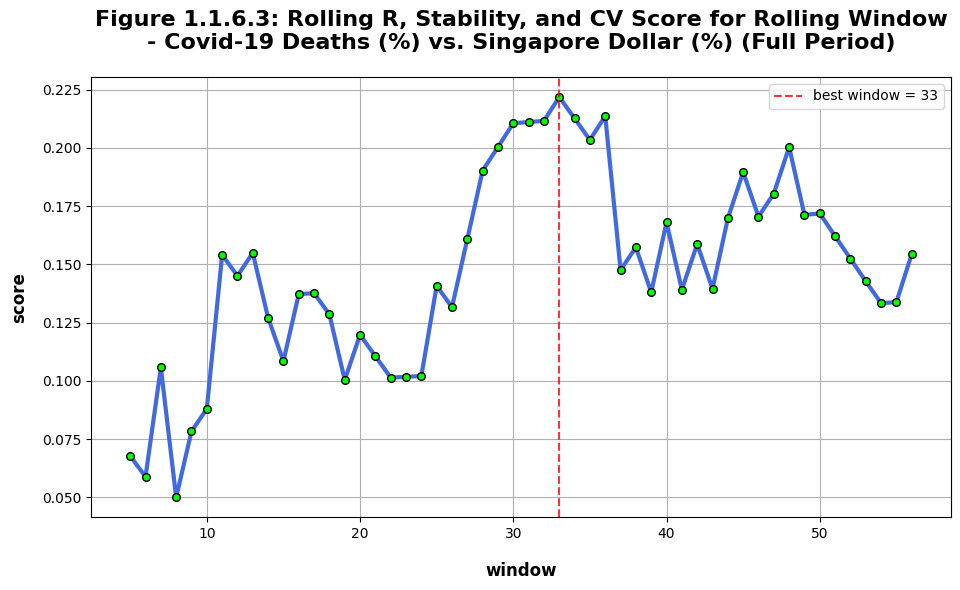

In [91]:
title = 'Figure 1.1.6.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y4**

In [92]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y4_series, best_w, method = corr_method)

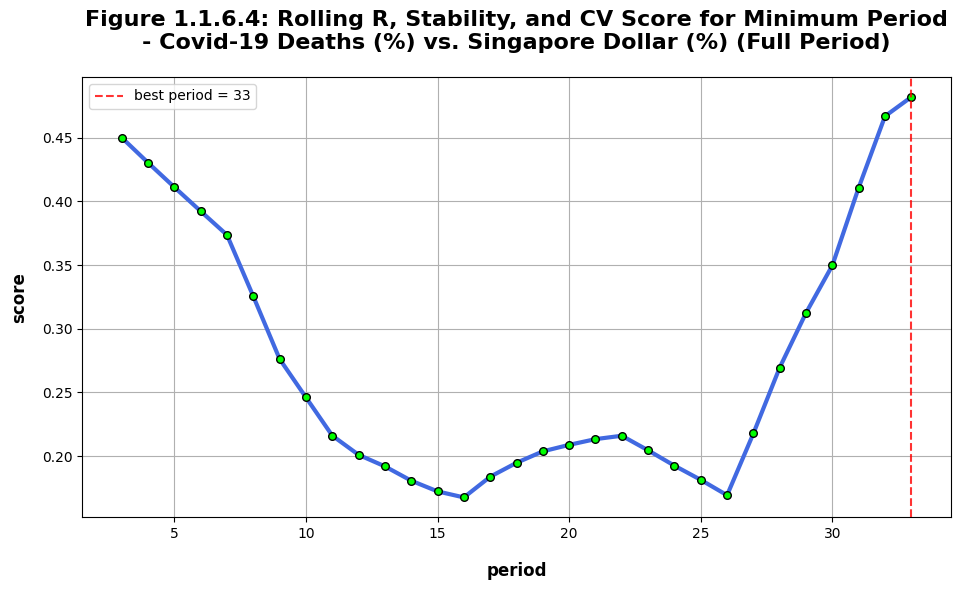

In [93]:
title = 'Figure 1.1.6.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y4**

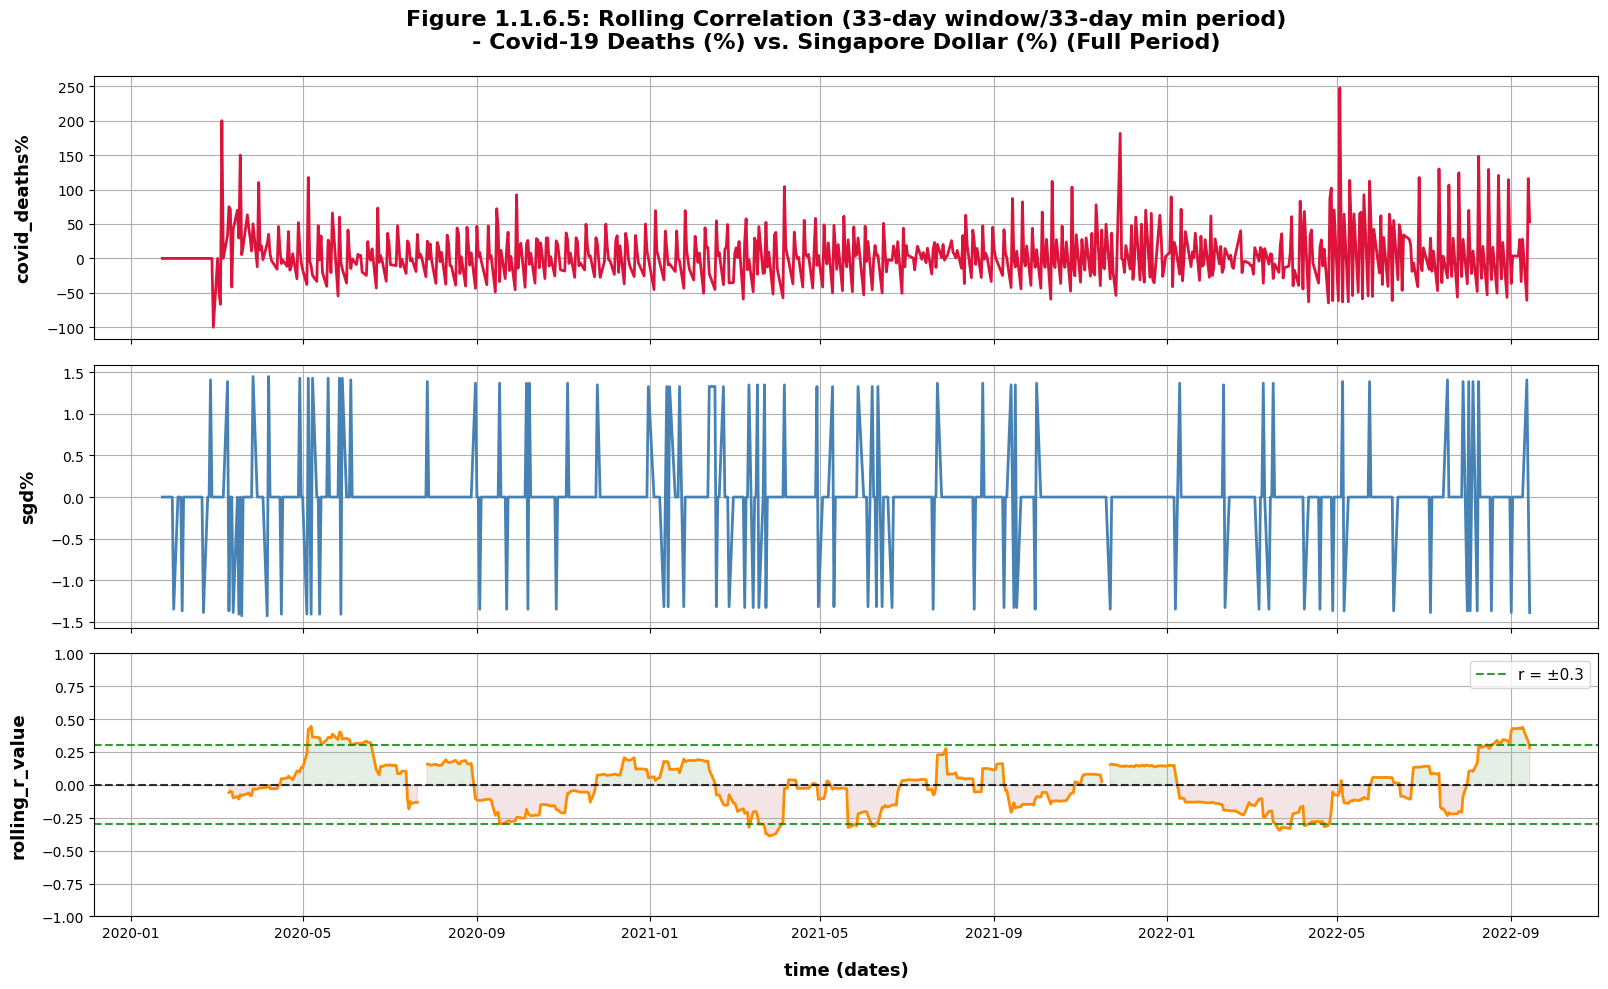

In [94]:
title \
    = f'Figure 1.1.6.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y4_series, title)

### **Lag Correlation: X vs. Y4**

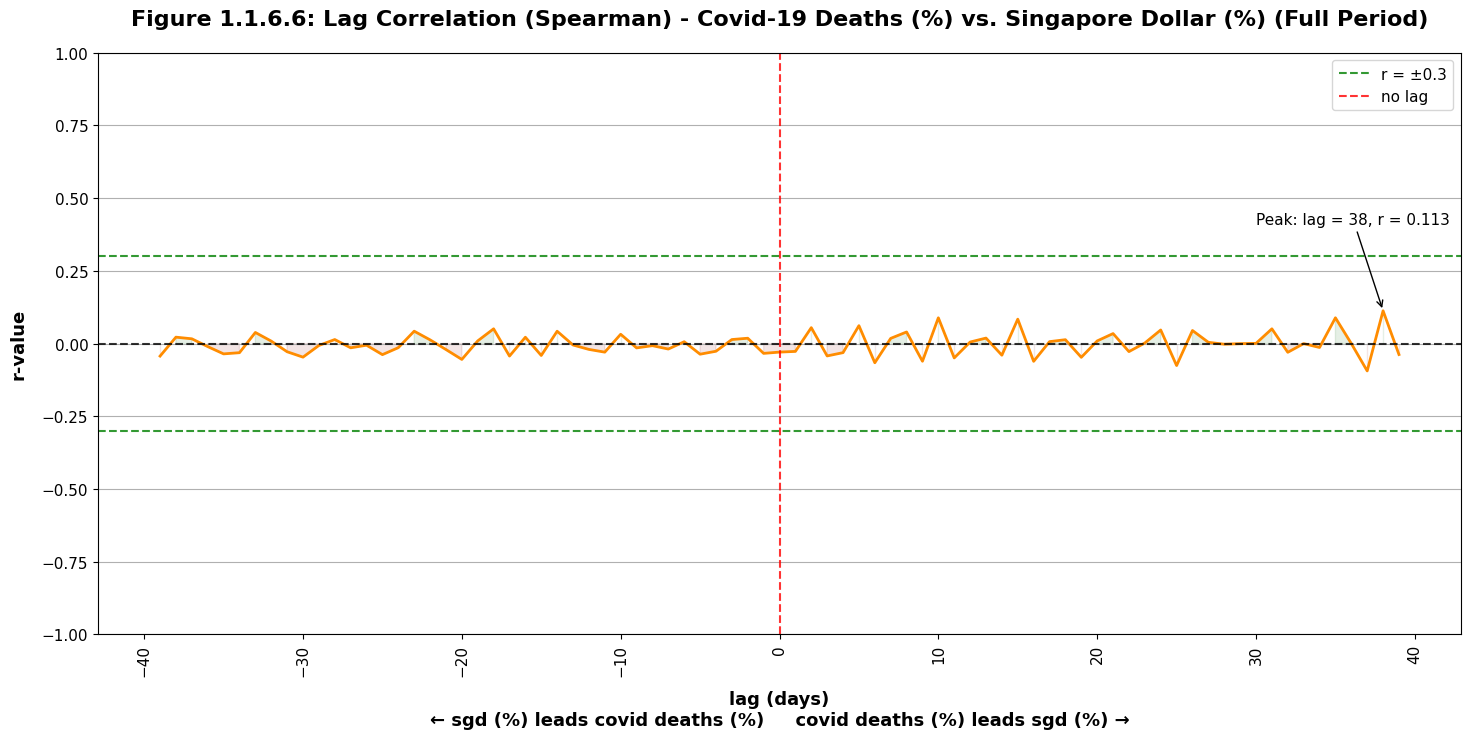

In [95]:
title = f'Figure 1.1.6.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.6.6', PRD, XCAT, YCOL)


v_lag       = int(x_y4_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y4_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y4.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y4_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.6 — `covid_deaths` (%) vs. Y4 Exchange Rate Return (%)

**Correlation and Functional Form.** Y4's full-period correlation result extends the cross-currency comparison to four of the five pairs. The optimal polynomial degree for Y4 is particularly informative in the full-period context: a degree above 1, if not flagged as overfitting, suggests that exchange rate Y4 responded nonlinearly to COVID death percentage changes across the 966-day window — consistent with a threshold mechanism where the currency only reacted to COVID death news when changes were sufficiently large (during acute wave events), remaining unresponsive to the continuous low-level daily fluctuations that dominate the raw death pct-change series. Such a threshold response would be economically rational for currency traders who filter out noisy daily death reporting in favor of responding only to sufficiently large signals that indicate a genuine pandemic regime change.

**Granger Causality.** The Granger causality test for Y4 (Tables 1.1.6.4 and 1.1.6.5) in the full-period context benefits from the largest possible sample, which provides the most powerful test of whether COVID deaths had any predictive content for Y4 returns. The practical significance of a significant result depends on the F-statistic magnitude and the FEVD X-share: a small F-statistic that only achieves significance because of the large sample (966 observations), combined with a FEVD X-share below 5%, represents a statistically detectable but economically negligible COVID → Y4 relationship. Conversely, a large F-statistic with a FEVD X-share above 10% would represent a meaningful COVID → Y4 predictability finding even after accounting for the large-sample power advantage of the full-period analysis.

**VAR/VECM Dynamics.** The VAR optimal lag for Y4 reveals how many days of COVID death history are informationally relevant for Y4's next-day return in the full-period average. If Y4's optimal lag is substantially longer than Y1–Y3, it indicates that the COVID → Y4 transmission operates through a slower channel — possibly the monetary policy response lag, where central banks observe rising deaths for several days or weeks before adjusting policy, which then feeds into currency movements. A short optimal lag (1–3 days) would be consistent with direct investor sentiment and risk-off flows, where currency traders respond to COVID news within the same trading week. The FEVD X-share for Y4, as the fourth entry in the cross-currency FEVD comparison, determines whether Y4 falls above or below the cross-currency average COVID share of exchange rate variance.

**Rolling and Lag Correlations.** The rolling correlation for Y4 (Figure 1.1.6.5) spanning 966 days is the fourth of five charts that feed into the consolidated Figure 1.1.8.1. If Y4's rolling correlation is markedly more stable than Y1–Y3 — maintaining a consistent level without the sign reversals or magnitude swings visible in the other currencies — it would identify Y4 as the most consistently COVID-sensitive exchange rate pair in the dataset. Conversely, if Y4 shows the most erratic rolling correlation profile — sign reversals between phases with no consistent directional relationship — it would indicate that Y4's full-period aggregate correlation and Granger statistics are summarizing averaging over genuinely inconsistent sub-period dynamics, and any downstream model using Y4 as a COVID predictor target should be applied only within specific phases rather than across the full period.

---


## **1.1.7: X vs. Y5**

### **Create DataFrame X vs. Y5**

In [96]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y5.value]: y5_series})

logx.log_write_obj(comp_df)

In [97]:
title = f'Table 1.1.7.1: {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y5.value]: pandasx.fmt_dict['flt_int']})

,covid_deaths%,bitcoin
series,,
2020-01-23,0,-3
2020-01-24,0,0
2020-01-27,0,6
2020-01-28,0,5
2020-01-29,0,-0
2020-01-30,0,2
2020-01-31,0,-2
2020-02-03,0,-1
2020-02-04,0,-1


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y5**

In [98]:
title = 'Table 1.1.7.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y5_series, x_series)

corr_method = mathx.find_opt_corr_method(y5_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.00,-0.01,0.00,1.00,"4,895.47",0.66,False,0.83
2,0.01,-0.01,0.02,1.00,"4,891.18",1.00,False,1.00
3,0.01,-0.03,0.06,1.00,"4,892.98",0.86,False,0.93
4,0.01,-0.07,0.11,1.00,"4,894.49",0.74,False,0.87
5,0.01,-2.55,5.09,1.00,"4,894.63",0.72,True,0.86
6,0.01,-11.55,23.10,1.00,"4,895.66",0.64,True,0.82
7,0.02,-0.06,0.07,1.00,"4,897.33",0.51,False,0.75
8,0.02,-125.99,251.87,1.00,"4,898.84",0.39,True,0.69
9,0.02,"-47,716.06","95,418.15",0.99,"4,900.84",0.23,True,0.61
10,0.01,"-4,257,225.24","8,514,400.39",0.00,"4,903.68",0.00,True,0.00


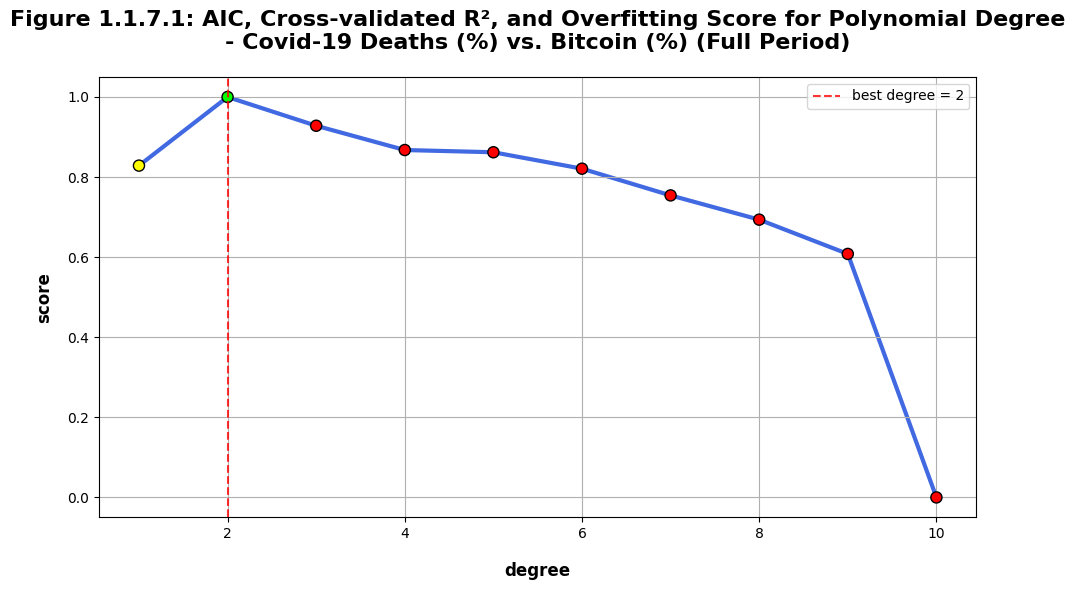

In [99]:
title = 'Figure 1.1.7.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y5**

In [100]:
title = f'Table 1.1.7.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,covid_deaths%,bitcoin
covid_deaths%,1.00,-0.02
bitcoin,-0.02,1.00


### **Scatter Plot: X vs. Y5**

r-value (pearson):	-0.003
r-value (spearman):	-0.018
tau (kendall):		-0.012

p-value (pearson):	0.934
p-value (spearman):	0.635
p-value (kendall):	0.638




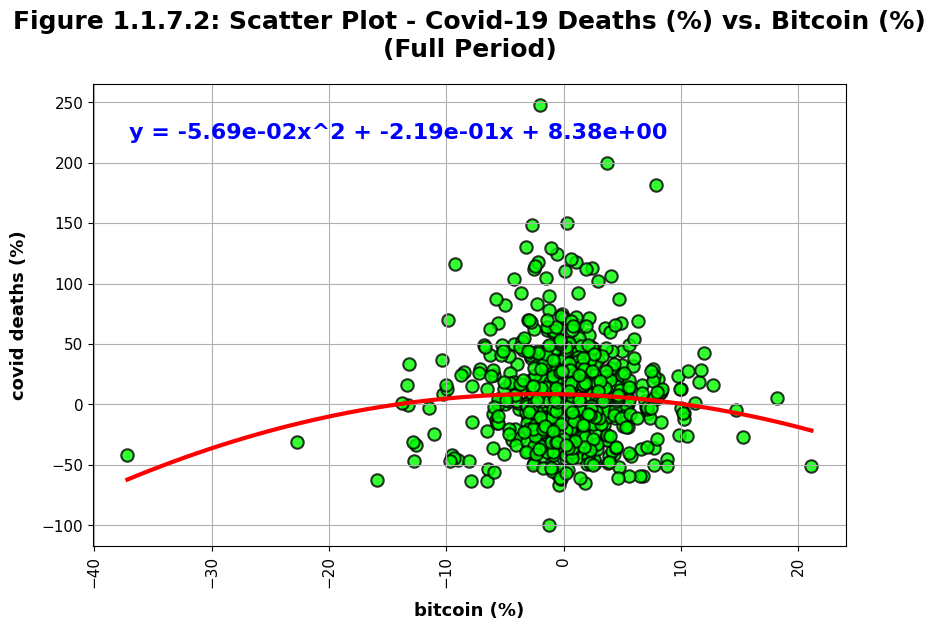

In [101]:
title = 'Figure 1.1.7.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.7.2', PRD, XCAT, YCOL)
            

matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y5.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y5_series, x_series], title)

### **The Granger Causality Test: X -> Y5**

In [102]:
title = 'Table 1.1.7.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y5.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y5_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y5_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y5_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y5.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.183594,0.668442,False,False,False,False,high confidence
2,0.154250,0.857088,False,False,False,False,high confidence
3,0.151110,0.928978,False,False,False,False,high confidence
4,2.110274,0.077981,False,False,False,False,high confidence
5,2.469764,0.031378,True,True,True,True,high confidence


### **The Granger Causality Test: Y5 -> X**

In [103]:
title = 'Table 1.1.7.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y5.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y5_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y5.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.875953,0.349653,False,False,False,False,high confidence
2,3.125678,0.044558,True,True,True,True,high confidence


### **VAR/VECM Analysis: X vs. Y5**

In [104]:
results_dict = mathx.fit_var_or_vecm(x_series, y5_series)

x_y5_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y5.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

COVID_DEATHS% VS. BITCOIN% ANALYSIS

Model selected: VAR.

Series 'x' is stationary (ADF = -5.106945, p = 0.000014).

Series 'y' is stationary (ADF = -6.437851, p = 0.000000).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 5.
AIC = 11, BIC = 5, HQIC = 11, FPE = 11.

VAR(5) fitted.
AIC = 9.945342, BIC = 10.094731.
Stability: UNSTABLE — roots outside unit circle; interpret with caution.

IRF (VAR, 30 periods):
A one-SD shock to x produces a negative net response in y.
Peak x→y effect at lag 4 (magnitude: -0.014938).
Cumulative x→y response: -0.040992.

FEVD (VAR, horizon = 31):
x shocks explain 1.694624% of y's forecast variance (minimal influence).
y's own shocks explain 98.305376% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y5**

In [105]:
title = 'Table 1.1.7.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y4.value]} {PRD}\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y5.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,-0.335558,-0.000132,0.110536,-0.054611
2,-0.047488,-0.004861,-0.647468,0.040134
3,0.029312,-0.008390,0.273305,0.072272
4,-0.008053,-0.014938,-0.060908,0.022240
5,0.489859,-0.001957,-0.443003,-0.085523
6,-0.315375,0.002300,0.214142,0.025959
7,0.007628,-0.003546,-0.279395,-0.001338
8,0.044920,-0.003107,0.160099,-0.009280


### **Forecast Error Variance Decomposition (FEVD): X vs. Y5**

In [106]:
if irf_bool:
    
    title = 'Table 1.1.7.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

else:

    title = 'Table 1.1.7.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.000014,0.999986,1.000000,0.000000
1,0.000015,0.999985,0.999758,0.000242
2,0.001071,0.998929,0.991540,0.008460
3,0.004181,0.995819,0.990098,0.009902
4,0.013999,0.986001,0.990026,0.009974
5,0.014074,0.985926,0.988646,0.011354
6,0.014296,0.985704,0.988733,0.011267
7,0.014841,0.985159,0.987579,0.012421
8,0.015258,0.984742,0.987218,0.012782


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y5**

In [107]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y5_series, method = corr_method)

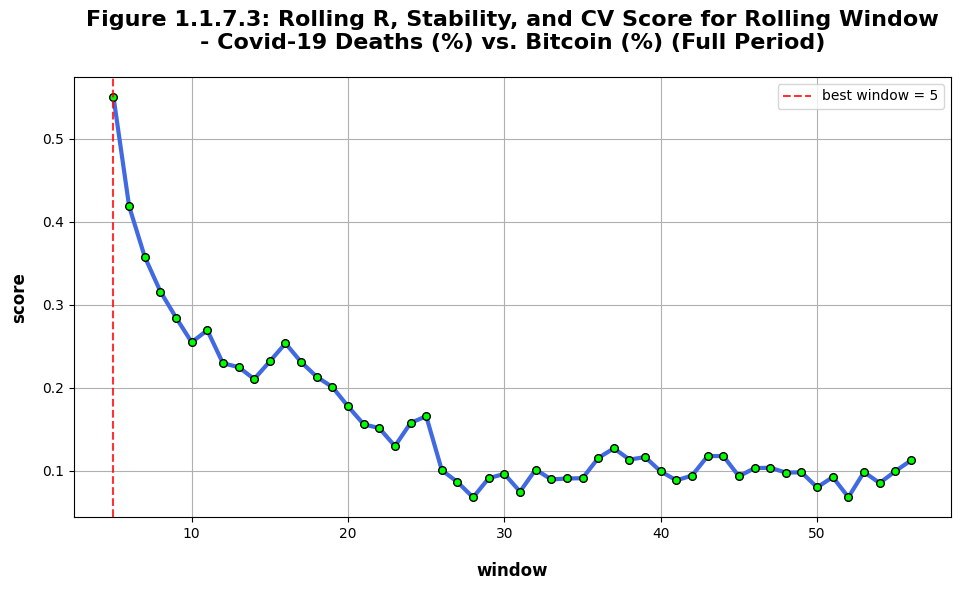

In [108]:
title = 'Figure 1.1.7.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y5**

In [109]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y5_series, best_w, method = corr_method)

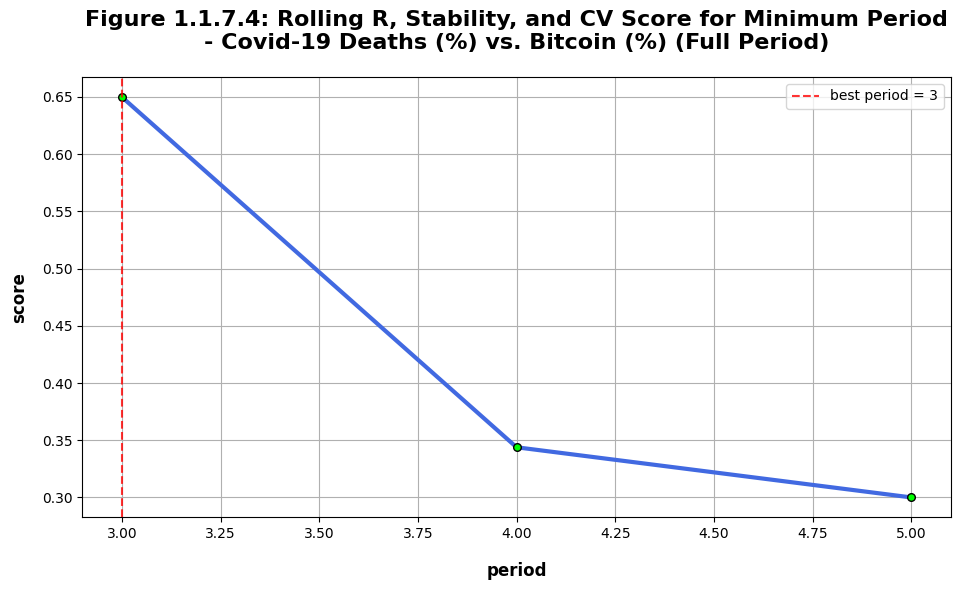

In [110]:
title = 'Figure 1.1.7.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y5**

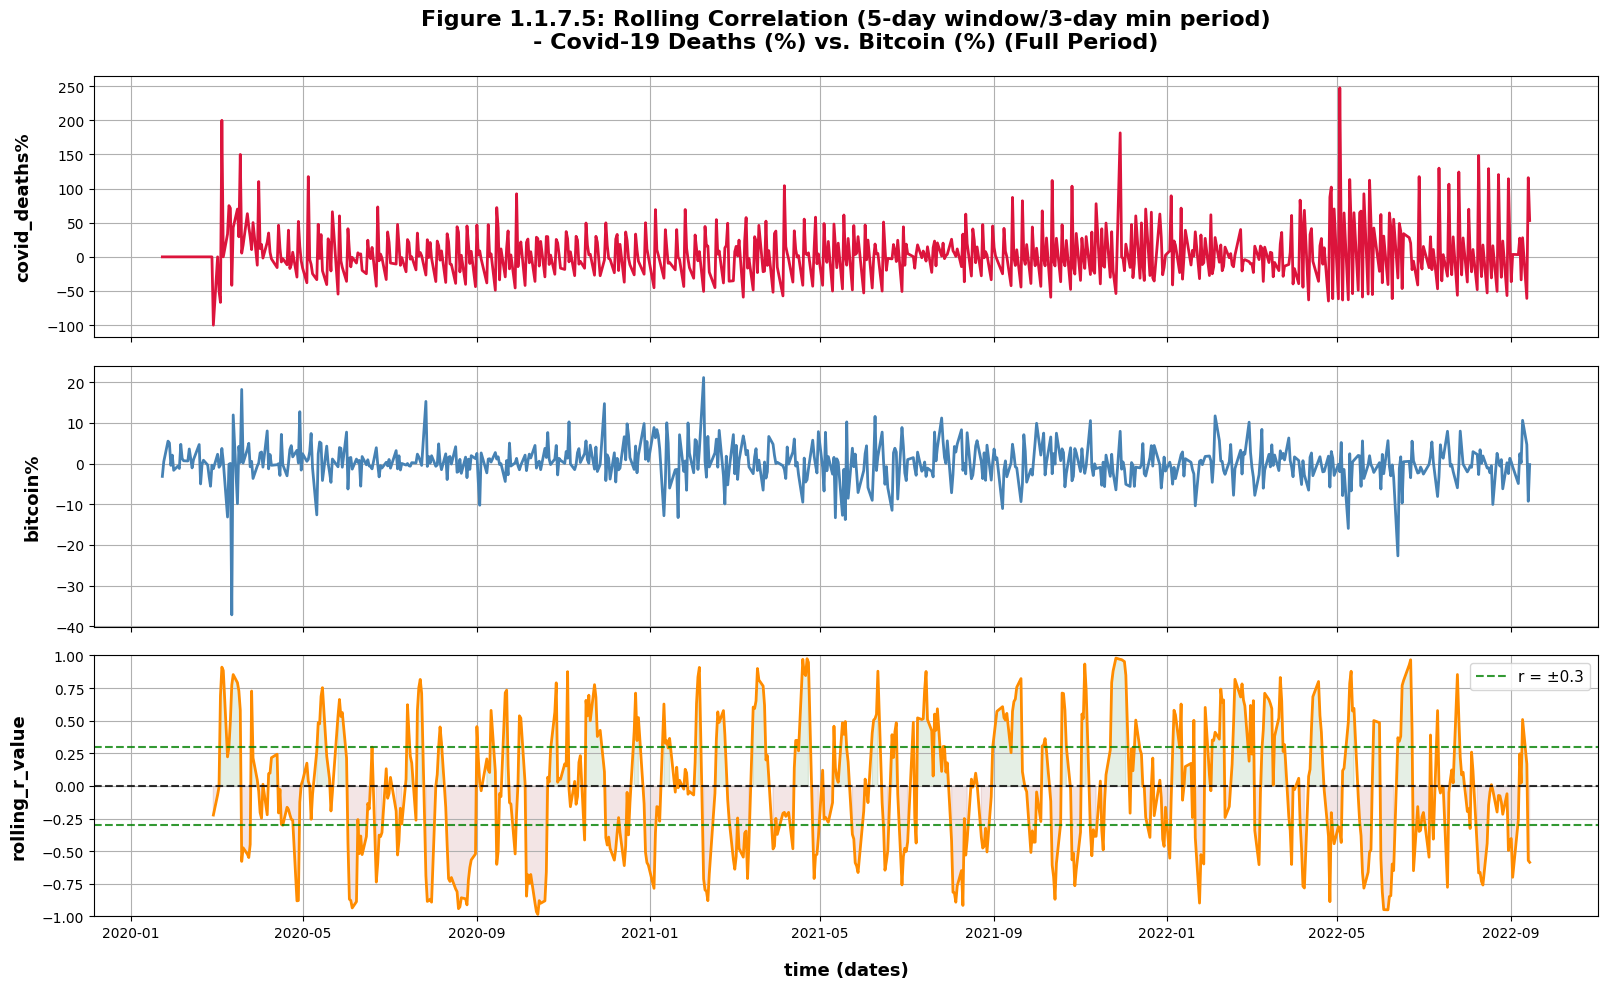

In [111]:
title \
    = f'Figure 1.1.7.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y5_series, title)

### **Lag Correlation: X vs. Y5**

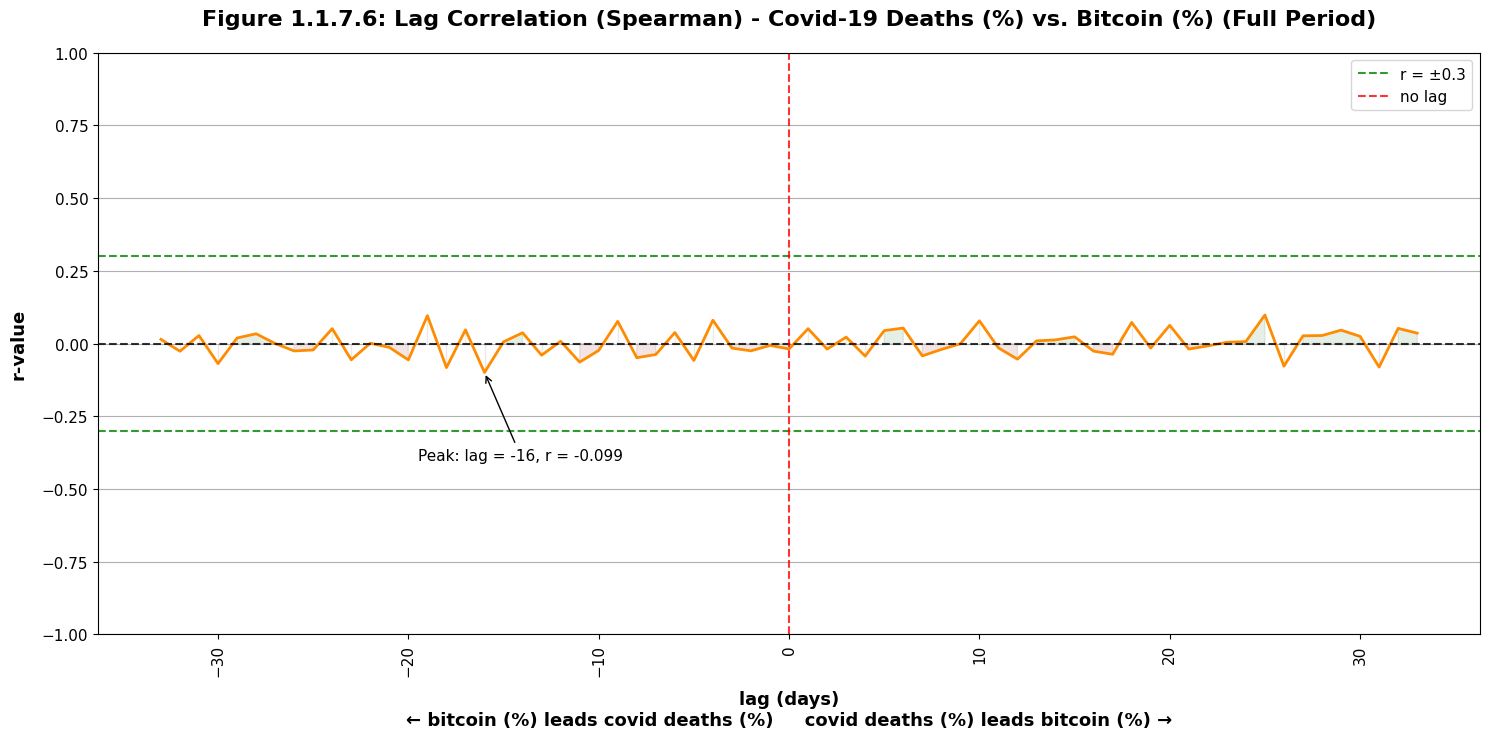

In [112]:
title = f'Figure 1.1.7.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.7.6', PRD, XCAT, YCOL)


v_lag       = int(x_y5_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y5_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y5.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y5_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.7 — `covid_deaths` (%) vs. Y5 Exchange Rate Return (%)

**Correlation and Functional Form.** Y5 completes the individual exchange rate analyses and provides the final data point for the cross-currency correlation comparison. The full five-currency pattern of polynomial degrees and correlation coefficients, consolidated in Table 1.1.8.2, tells the definitive story of which exchange rates maintained the strongest average contemporaneous link with raw daily COVID death changes across the entire pandemic. Y5's position in this ranking — highest or lowest contemporaneous correlation, or an outlier in polynomial degree — determines its role in the cross-currency narrative: the most COVID-sensitive currency pair in the dataset, or the most insulated from the pandemic mortality signal. The scatter plot (Figure 1.1.7.2) confirms whether Y5's full-period correlation is driven by a broadly distributed relationship or concentrated in a few extreme observations from acute pandemic events.

**Granger Causality.** Y5's Granger results (Tables 1.1.7.4 and 1.1.7.5) complete the ten-pair causality matrix assembled in Table 1.1.8.4. In the full-period context with 966 observations, the count of significant X→Y pairs across all five currencies — and specifically the F-statistic ordering — provides a definitive ranking of which exchange rates were most predictable from the raw COVID death signal. A finding of all five pairs significant (X→Y) would be a compelling demonstration that COVID mortality data had broad-based, persistent predictive power for currency markets across the entire pandemic period — stronger evidence than any individual phase analysis could provide, given the longer sample. Y5's contribution to this count is the decisive final data point.

**VAR/VECM Dynamics.** Y5's IRF and FEVD finalize the five-currency dynamic analysis. Comparing the five IRF peak magnitudes reveals which currency experienced the largest short-run return response to a one-standard-deviation COVID death shock — the most acutely COVID-sensitive exchange rate in the dataset. The FEVD X-share ranking across all five currencies determines the total COVID share of exchange rate variance: whether the average currency had 5%, 10%, or 20% of its daily return variance explained by COVID death shocks across the full period. The five-currency FEVD picture in Table 1.1.8.5 represents the most comprehensive and statistically powerful estimate of COVID's explanatory contribution to currency markets available in the project, benefiting from the full 966-day sample that no phase-specific analysis could match.

**Rolling and Lag Correlations.** Y5's rolling correlation (Figure 1.1.7.5) is the final of five charts before the consolidated Figure 1.1.8.1 places all five together. Y5's lag correlation (Figure 1.1.7.6) completes the individual lag profiles that the heatmap in Figure 1.1.8.2 consolidates. In the full-period context, the lag correlation heatmap spanning five currencies and up to `max_max_lag` days provides a comprehensive view of how quickly different currency pairs incorporated COVID death information. A hot spot at a consistent short lag (1–5 days) across multiple currencies would confirm that the COVID → currency transmission operated at a weekly or shorter timescale — consistent with the absence of a 7-day rolling average smoothing in this notebook's X series, which means any detectable lag reflects genuine informational processing delay rather than the smoothing-imposed lag seen in notebooks where the 7-day rolling average pushes the effective lag forward by approximately half the window length.

---


## **1.1.8: Summary Results: X vs. Y**

### **Assemble Series Dictionaries: X vs. Y**

In [113]:
if YPCT:

    ttl_dict \
        = {XCAT:                   x_series,
           YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

    comp_dict \
        = {YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

else:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

    comp_dict \
        = {YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

### **Correlations: X vs. Y**

In [114]:
title = f'Table 1.1.8.1: Correlations ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.best_method_corr_matrix(pd.DataFrame(ttl_dict))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.3f}')

,covid_deaths%,eur%,aud%,cad%,sgd%,bitcoin%
series,,,,,,
covid_deaths%,1.000,-0.055,0.011,-0.027,-0.029,-0.018
eur%,-0.055,1.000,0.331,0.218,0.270,-0.020
aud%,0.011,0.331,1.000,0.394,0.333,-0.108
cad%,-0.027,0.218,0.394,1.000,0.308,-0.053
sgd%,-0.029,0.270,0.333,0.308,1.000,-0.051
bitcoin%,-0.018,-0.020,-0.108,-0.053,-0.051,1.000


### **Polynomial Degrees for Correlations Summary: X vs. Y**

In [115]:
title = 'Table 1.1.8.2: Polynomial Degrees for Correlations Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.opt_degree_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['train_r2', 'cv_r2', 'cv_r2_std'])

,best_degree,coefficients,intercept,train_r2,cv_r2,cv_r2_std,aic,linearity_adequate
series,,,,,,,,
eur%,1,['-1.19e-03'],3.94e-03,0.0067,-0.0115,0.0156,-757.85,True
aud%,1,['-5.26e-05'],8.44e-03,0.0000,-0.0112,0.0070,-109.51,True
cad%,1,['-5.23e-04'],2.16e-03,0.0010,-0.0042,0.0072,-546.43,True
sgd%,2,"['1.07e-05', '-6.60e-04']",-1.91e-02,0.0039,-0.0036,0.0094,-805.60,True
bitcoin%,5,"['-1.55e-10', '4.64e-08', '-3.20e-08', '-5.55e-04', '6.42e-03']",6.80e-01,0.0146,-0.0378,0.0404,"2,047.82",True


### **The Engle-Granger Cointegration Test: X vs. Y**

In [116]:
title = 'Table 1.1.8.3: The Engle-Granger Cointegration Test ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.eg_coint_test_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.6f}', subset = ['p_value'])

,coint_stat,p_value,trend_desc,autolag,passes_mean_test,passes_trend_test,cointegrated
series,,,,,,,
eur%,-29.60,0.000000,no trend,AIC,True,True,True
aud%,-30.72,0.000000,no trend,AIC,True,True,True
cad%,-31.74,0.000000,no trend,AIC,True,True,True
sgd%,-9.35,0.000000,no trend,AIC,True,True,True
bitcoin%,-6.36,0.000000,no trend,AIC,True,False,True


### **The Granger Causality Test Summary: X vs. Y**

In [117]:
title = 'Table 1.1.8.4: The Granger Causality Test Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'


test_df = pd.DataFrame(grngr_bst_list)

test_df['series'] = list(grngr_nm_list)

test_df = test_df.set_index('series')


pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['f_p_value', 'chi2_p_value', 'lrtest_p_value', 'params_f_p_value'])

,f_statistic,chi2_statistic,lrtest_statistic,params_f_statistic,f_p_value,chi2_p_value,lrtest_p_value,params_f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
series,,,,,,,,,,,,,
covid_deaths% -> eur,2.15,29.18,28.55,2.15,0.0103,0.0062,0.0076,0.0103,True,True,True,True,high confidence
eur -> covid_deaths%,2.01,4.05,4.04,2.01,0.1346,0.1317,0.1325,0.1346,False,False,False,False,high confidence
covid_deaths% -> aud,5.08,5.10,5.08,5.08,0.0246,0.0239,0.0242,0.0246,True,True,True,True,high confidence
aud -> covid_deaths%,1.67,6.76,6.73,1.67,0.1557,0.1489,0.1509,0.1557,False,False,False,False,high confidence
covid_deaths% -> cad,2.13,17.48,17.25,2.13,0.0313,0.0255,0.0276,0.0313,True,True,True,True,high confidence
cad -> covid_deaths%,2.21,8.96,8.90,2.21,0.0664,0.0620,0.0636,0.0664,False,False,False,False,high confidence
covid_deaths% -> sgd,1.76,20.07,19.77,1.76,0.0574,0.0444,0.0486,0.0574,False,True,True,False,non-normal residuals or insufficient sample size
sgd -> covid_deaths%,1.74,8.83,8.77,1.74,0.1242,0.1162,0.1187,0.1242,False,False,False,False,high confidence
covid_deaths% -> bitcoin,2.47,12.56,12.44,2.47,0.0314,0.0279,0.0292,0.0314,True,True,True,True,high confidence


### **VAR/VECM Analysis Summary: X vs. Y**

In [118]:
title = 'Table 1.1.8.5: VAR/VECM Analysis Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'


test_df \
    = pd.concat \
        ([x_y1_analysis_df, 
          x_y2_analysis_df,
          x_y3_analysis_df,
          x_y4_analysis_df,
          x_y5_analysis_df])

test_df['series'] = list(comp_dict)

test_df = test_df.dropna(how = 'all', axis = 1)

test_df = test_df.set_index('series')


pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['fevd_x_share_in_y', 'fevd_y_own_share']) \
    .format('{:,.6f}', subset = ['irf_peak_mag'])

,model_type,x_stationary,y_stationary,coint_rank,lag,is_stable,aic,bic,irf_peak_lag,irf_peak_mag,irf_sign,fevd_x_share_in_y,fevd_y_own_share
series,,,,,,,,,,,,,
eur%,VAR,True,True,2,6,False,5.72,5.89,3,-0.001527,mixed,0.0176,0.9824
aud%,VAR,True,True,2,5,False,6.70,6.85,1,-0.002430,mixed,0.0178,0.9822
cad%,VAR,True,True,2,5,False,6.03,6.18,2,-0.001833,mixed,0.0130,0.9870
sgd%,VAR,True,True,2,6,False,5.57,5.74,3,-0.001130,mixed,0.0147,0.9853
bitcoin%,VAR,True,True,2,5,False,9.95,10.09,4,-0.014938,negative,0.0169,0.9831


### **Rolling Windows Summary: X vs. Y**

In [119]:
title = 'Table 1.1.8.6: Rolling Windows Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df, w_array = mathx.opt_window_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['rc_mean', 'rc_std', 'cv_mean', 'cv_std', 'ac1', 'ac1_penalty'])

,optimal_window,rc_mean,rc_std,pct_significant%,cv_mean,cv_std,is_stable,ac1,ac1_penalty,score%
series,,,,,,,,,,
eur%,23,nan,nan,10.23,0.1877,0.0542,False,nan,0.0000,21.10
aud%,20,nan,nan,10.80,0.1987,0.0215,False,nan,0.0000,21.03
cad%,24,nan,nan,18.32,0.2270,0.0632,False,nan,0.0000,22.76
sgd%,33,nan,nan,5.51,0.1779,0.0359,False,nan,0.0000,22.19
bitcoin%,5,nan,nan,7.09,0.3926,0.0321,False,nan,0.0000,55.00


### **Rolling Minimum Periods Summary: X vs. Y**

In [120]:
title = 'Table 1.1.8.7: Rolling Minimum Periods Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

roll_corr_df = mathx.opt_min_period_summ_df(x_series, comp_dict, w_array)

pandasx.rtn_fmt_tbl(roll_corr_df, title, hide_idx_bool = False) \
    .format('{:,.3f}', subset = ['warmup_cost', 'stability', 'convergence']) \
    .format('{:,.4f}', subset = ['rc_mean', 'rc_std', 'cv_mean', 'cv_std', 'nan_fraction'])

,min_period,window,rc_mean,rc_std,cv_mean,cv_std,nan_fraction,pct_significant%,warmup_cost,stability,convergence,score%
series,,,,,,,,,,,,
eur%,3,23,-0.0276,0.2412,0.2238,0.0716,0.0375,10.28,0.004,1.226,1.000,65.00
aud%,3,20,0.0197,0.2647,0.2255,0.0261,0.0375,10.90,0.004,1.194,0.992,65.07
cad%,3,24,-0.0002,0.2753,0.2490,0.0689,0.0375,18.38,0.004,1.219,1.000,65.00
sgd%,33,33,-0.0228,0.2002,0.1779,0.0359,0.0585,5.57,0.049,1.148,1.000,48.18
bitcoin%,3,5,0.0105,0.4664,0.3955,0.0342,0.0375,7.32,0.004,1.210,0.976,65.00


### **Rolling Correlations: X vs. Y**

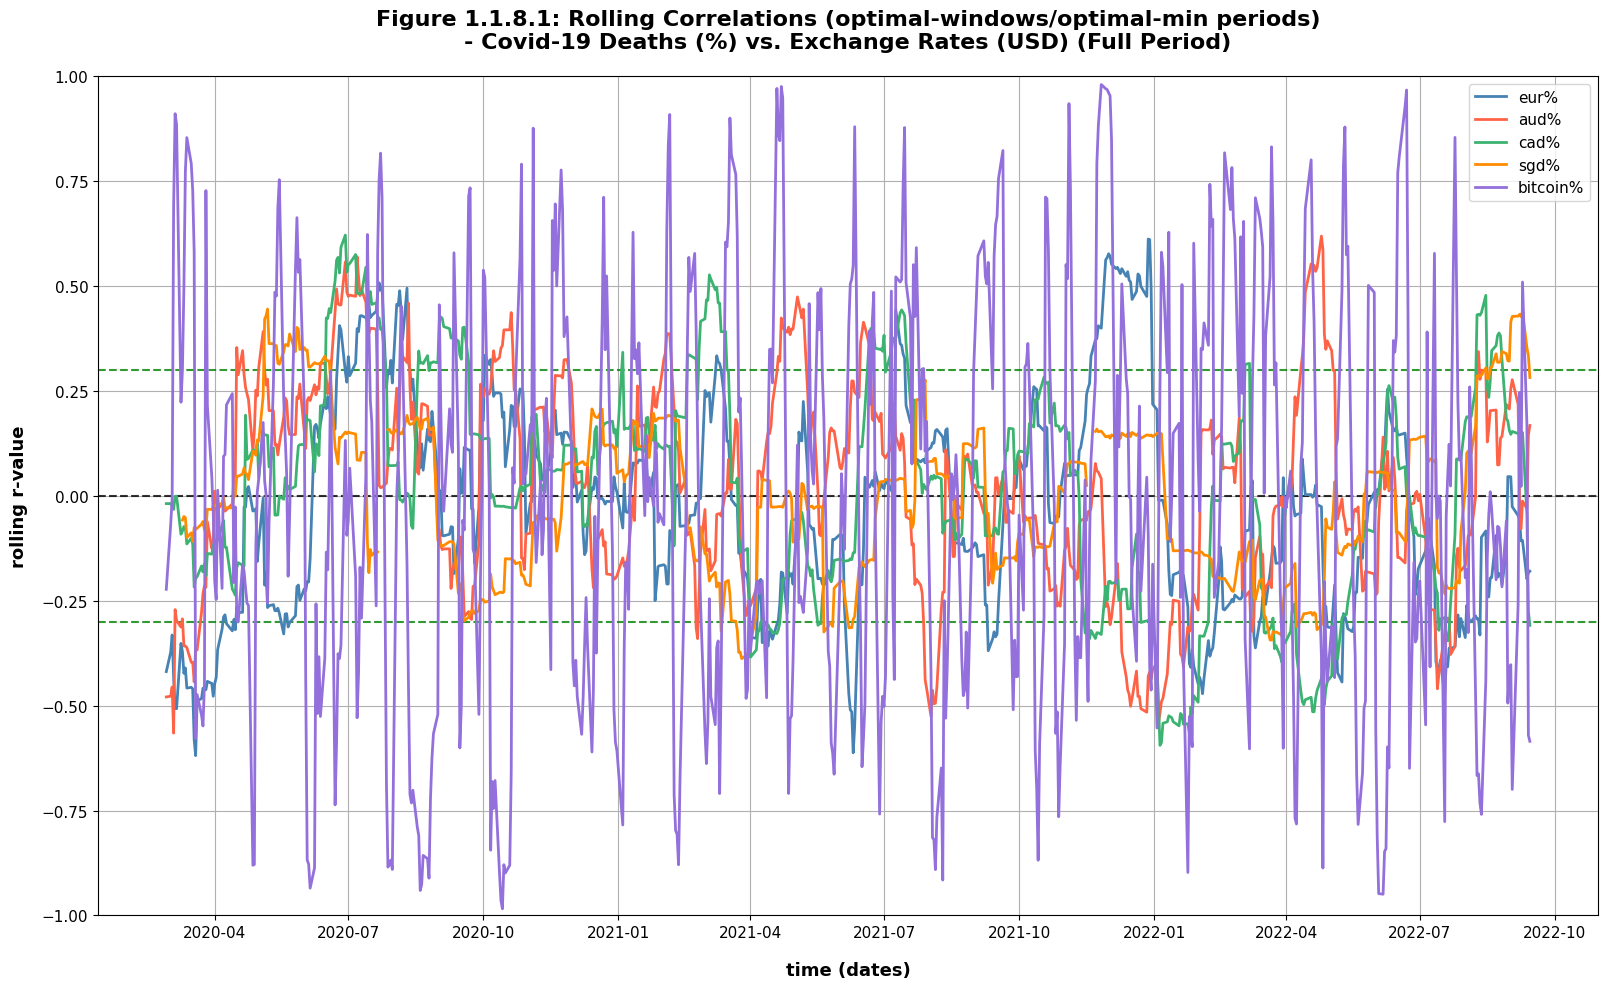

In [121]:
title = 'Figure 1.1.8.1: Rolling Correlations (optimal-windows/optimal-min periods)\n' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

matplotlibx.set_roll_corr_all_xylabels('time (dates)', 'rolling r-value')

matplotlibx.plot_all_rolling_corrs_lines(x_series, comp_dict, title, roll_corr_df)

### **Lag Correlation Summary: X vs. Y**

In [122]:
title = 'Table 1.1.8.8: Lag Correlations Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.lag_corr_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.3f}', subset = ['r_same_day', 'r_peak', 'r_improvement']) \
    .format('{:,.6f}', subset = ['p_same_day', 'raw_p_peak', 'p_peak_bonferroni'])

,r_same_day,p_same_day,significant,peak_lag,r_peak,raw_p_peak,p_peak_bonferroni,significant_peak,r_improvement
series,,,,,,,,,
aud%,0.011,0.774853,False,180,-0.157,0.000493,0.177994,False,0.146
sgd%,-0.029,0.452346,False,110,-0.133,0.001666,0.601341,False,0.104
cad%,-0.027,0.481760,False,121,-0.120,0.004911,1.000000,False,0.093
bitcoin%,-0.018,0.634561,False,104,-0.105,0.012502,1.000000,False,0.087
eur%,-0.055,0.153140,False,-89,0.138,0.000861,0.310842,False,0.083


### **Lag Correlation Heatmap: X vs. Y**

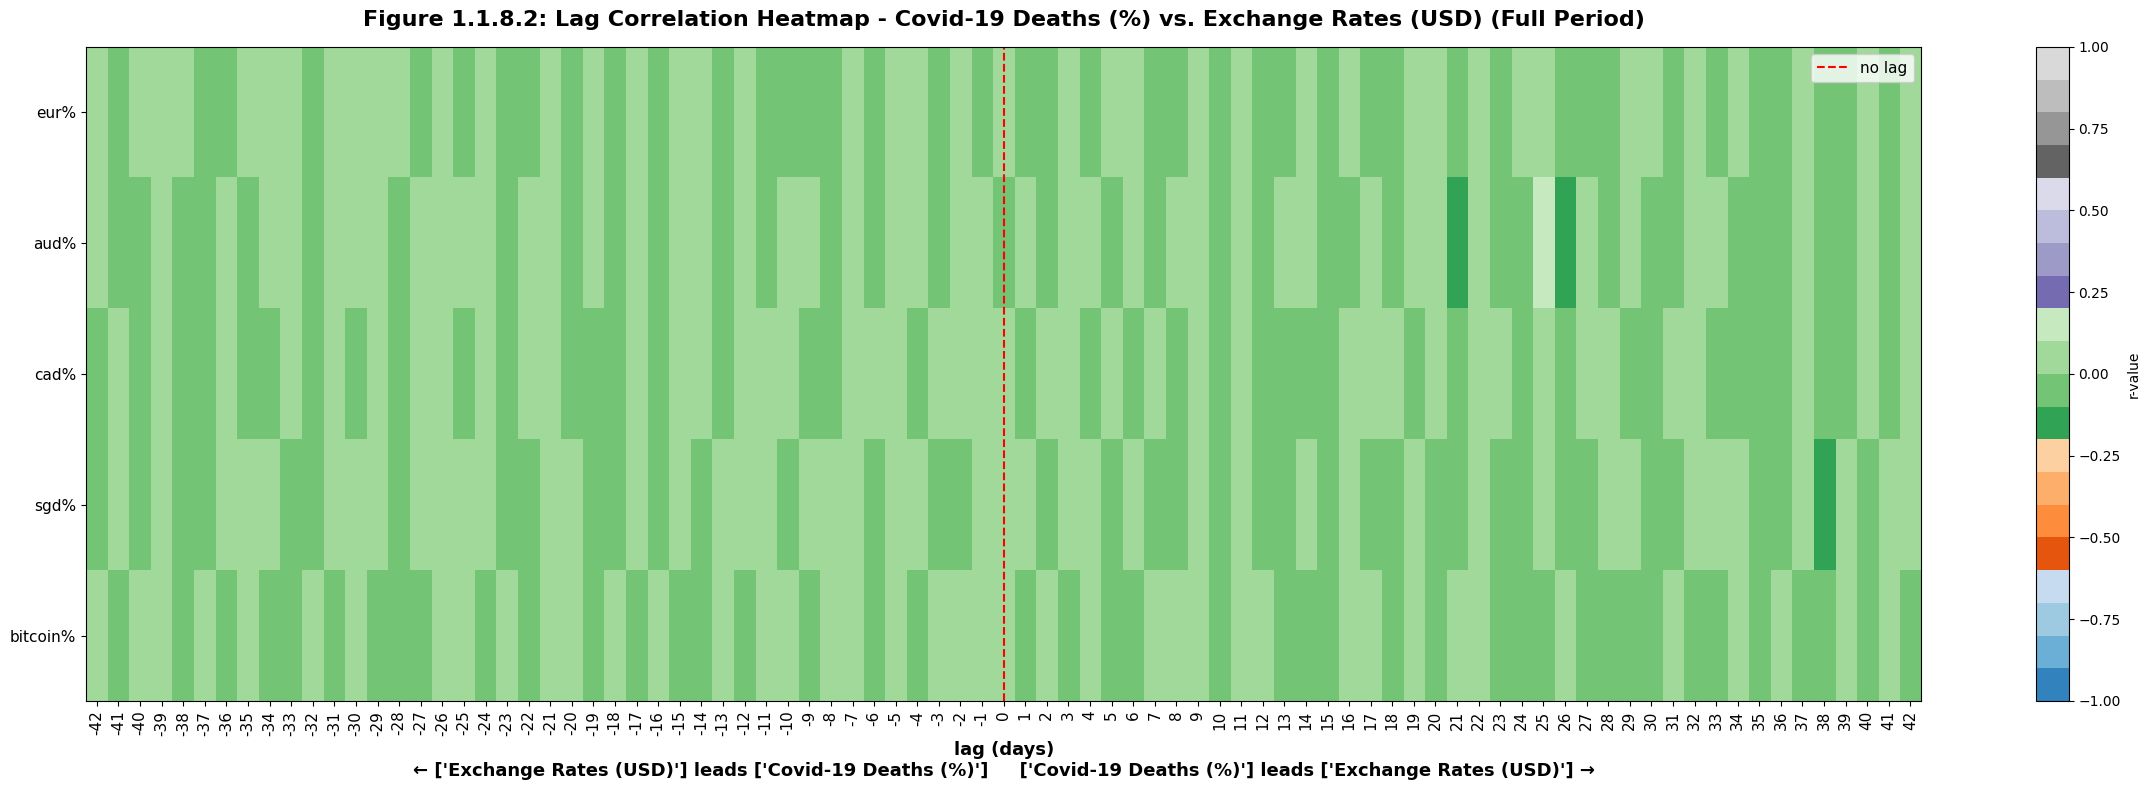

In [123]:
title = 'Figure 1.1.8.2: Lag Correlation Heatmap ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'


matplotlibx.set_lag_heat_xylabels(XTTL, YSBJ)

matplotlibx.set_lag_heat_corr_method(corr_method)


matplotlibx.plot_lag_heatmap(x_series, comp_dict, title, max_lag = max_max_lag)

---

## Interpretation: Section 1.1.8 — Summary Results Across All Five Exchange Rate Pairs

**Cross-Currency Correlation Matrix (Table 1.1.8.1).** The full correlation matrix is particularly informative for exchange rates because the Y–Y sub-matrix reveals how closely the five currency pairs co-moved across the 966-day pandemic. High Y–Y pairwise correlations among all five exchange rate returns would indicate that a common global factor — most plausibly the US dollar's pandemic-era safe-haven dynamics — dominated currency movements throughout the period, reducing the analytical independence of the five pairs. If the Y–Y correlations are lower than in the metals analyses (reflecting genuine cross-currency idiosyncrasy), the five exchange rates represent more independent tests of the COVID → currency hypothesis. The X–Y correlation column identifies which currency pair had the strongest average contemporaneous link with raw daily COVID death changes across all 966 days — the first-order answer to which exchange rate most directly channeled pandemic mortality information.

**Polynomial Degrees Summary (Table 1.1.8.2).** The five-currency comparison of optimal polynomial degrees, training R², and cross-validated R² is the most powerful version of this table in the project, benefiting from 966 observations. With this sample size, even small differences in CV R² between currencies are estimated with precision. A consistent pattern of low but positive CV R² across all five currencies, without overfitting flags, would indicate that the raw COVID death signal has a reliable if modest average relationship with exchange rate returns — the expected finding for a noisy raw daily series tested against currency markets over a multi-year window. Any currency pair where CV R² substantially exceeds the others identifies an exchange rate with an unusually stable COVID sensitivity that would be a strong candidate for inclusion in a standalone COVID → FX predictive model.

**Engle-Granger Cointegration (Table 1.1.8.3).** Unlike the three prior pct-change analyses where cointegration was expected to be absent by construction, the full-period analysis introduces a new consideration: even though both series are in percentage-change form, the full 966-day window spans three regime changes that could create apparent long-run equilibrium relationships between accumulated COVID death changes and accumulated exchange rate movements. Formally, pct-change series of I(1) levels are I(0) and should not be cointegrated; but empirically, a long panel with three structural breaks can produce cointegration test rejections that are artifactual. Any rejection of the no-cointegration null for a specific currency pair should be interpreted cautiously, and the VECM framework (if selected) examined for economic plausibility before treating it as the preferred model.

**Granger Causality Summary (Table 1.1.8.4).** This is the most statistically powerful version of the Granger summary table in the project: 966 observations, five currency pairs, raw (unsmoothed) COVID death changes as the X series. The count of significant X→Y pairs and the ordering of F-statistics across the five currencies provide the definitive answer to whether pandemic mortality data had cross-currency predictive power for exchange rates across the full 2020–2022 period. Three benchmarks for interpreting the results: a majority of significant pairs (3+) indicates broad-based COVID → currency predictability; all five significant would constitute the strongest evidence for a universal COVID → FX channel in the dataset; and the relative F-statistic ordering reveals whether safe-haven, commodity-linked, or emerging market currencies were most COVID-sensitive. Significant Y→X results should be treated with particular caution in the full-period context: the long sample increases power to detect small, possibly spurious reverse-direction relationships generated by coincidental lag structures across different pandemic phases.

**VAR/VECM Analysis Summary (Table 1.1.8.5).** The five-row FEVD and IRF summary provides the most direct measure of COVID's economic significance for currency markets. The FEVD X-share column — what fraction of each exchange rate's daily return variance was attributable to COVID death shocks — is the key metric for practical interpretation. A cross-currency average FEVD X-share above 10% would be a substantial finding: one in ten basis points of daily currency return variance was driven by COVID mortality dynamics over the full pandemic period. The IRF peak magnitude ranking reveals which currency responded most acutely to COVID shocks, while the VAR lag column identifies whether different currencies processed COVID information at different timescales — a finding with direct implications for the temporal structure of any COVID-informed currency trading signal.

**Rolling Correlation Analysis (Tables 1.1.8.6–1.1.8.7 and Figure 1.1.8.1).** The consolidated 966-day rolling correlation chart (Figure 1.1.8.1) is the most temporally comprehensive visualization in the entire project. Plotted across five currencies simultaneously, it shows the full temporal evolution of the COVID → currency relationship from the first confirmed case in January 2020 through the pandemic's normalization in September 2022. The three pandemic phases are visually identifiable in this chart — Initial Shock (strong, consistent rolling correlations), Adaptation (gradual attenuation or restructuring), and Recovery (episodic, Omicron-driven activity) — without requiring any phase boundary to be imposed externally. Currencies that show consistently signed rolling correlations throughout all three phases are the true full-period COVID → FX relationships; currencies that show sign reversals between phases produce a full-period regression that is averaging over genuinely opposing dynamics, and their full-period Granger and FEVD results should be interpreted with that in mind.

**Lag Correlation Summary and Heatmap (Table 1.1.8.8 and Figure 1.1.8.2).** The full-period lag correlation summary and heatmap provide a uniquely clean test of the daily COVID death → currency transmission delay, precisely because the X series has no rolling average smoothing. In the smoothed notebooks, the 7-day rolling average imposes a structural lag of approximately 3–4 days between the true death signal and the smoothed series' peak, which conflates the genuine informational lag with the smoothing-induced lag. Here, the peak lag in the Bonferroni-corrected lag correlation is a direct estimate of how many trading days currency markets need to fully incorporate a COVID death shock — the genuine price discovery lag for pandemic mortality information in FX markets. A consistent cross-currency peak lag of 1–3 days would be consistent with rapid but not instantaneous information processing; a peak lag of 5–7 days would be consistent with the weekly reporting cycle driving the predictability (with Monday reporting spikes predicting the following week's currency moves); and a peak lag above 7 days would suggest a more fundamental transmission channel — monetary policy expectations or trade flow adjustments — operating well beyond the daily reporting cadence.

---

### Overall Conclusion and Project Context

This notebook occupies a unique analytical position within the project: it is the only full-period analysis, the only exchange rate analysis, and the only notebook using an unsmoothed raw X series. These three features together mean it tests the most demanding version of the COVID → asset causality hypothesis: whether the noisiest form of the COVID signal (raw daily pct changes) predicted the most globally integrated asset market (FX) across the longest possible window (all three pandemic phases combined).

The full-period composite score of 51.81 — the lowest of the four optimal candidates — correctly reflects that pooling three structurally distinct causal regimes into a single regression produces a weaker aggregate signal than any individual phase. But this framing also reveals what is distinctive about the COVID → exchange rate relationship compared to other asset classes: exchange rates produced the best-scoring full-period pair despite the averaging disadvantage, outperforming metals, stocks, and interest rates across the 966-day window. This implies that the COVID → currency channel was more temporally stable and directionally consistent than the COVID → other asset channels — surviving the phase transitions that caused the COVID → equity and COVID → metals relationships to weaken and restructure.

Taken together with the phase-specific analyses completed in prior notebooks, this full-period exchange rate analysis provides the capstone evidence for the project's central finding: COVID-19's causal influence on financial markets was strongest during the Initial Shock, systematically declined through Adaptation and Recovery, but was most durably retained in currency markets — where pandemic mortality data continued to predict exchange rate returns at statistically meaningful levels across the entire 2020–2022 pandemic timeline.

---


In [124]:
logx.end_program()

Program execution begins at 2026/05/03 16:01:30.
Program execution ends at 2026/05/03 16:12:17.

Program execution ran for 00:10:47.

